# **1. Data Exploration & Visualization**

In this section, the dataset is explored to understand its structure, features, and overall characteristics. This includes inspecting the data, analyzing data types, checking for missing values, and studying statistical summaries. Various visualizations are used to identify patterns, distributions, and relationships within the dataset.

**Step 1: Load and Inspect Data**

In [ ]:
import pandas as pd

train = pd.read_csv("train.csv", low_memory=True)
test = pd.read_csv("test.csv", low_memory=True)

# Basic info
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train columns:", train.columns)
train.head()

Train shape: (288000, 2)
Test shape: (72000, 2)
Train columns: Index(['text', 'rating'], dtype='object')


,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1
3,"To find it, either park in front of the Tuesda...",4
4,Mall location. Used their services for sedan. ...,4


**Explanation**

The dataset contains 288,000 rows and 2 columns, indicating a large collection of review data. The two columns are:
*   text: Contains the customer reviews (input feature)
*   rating: Represents the corresponding rating (target variable)

**Step 2: Dataset Overview**

In [ ]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    288000 non-null  object
 1   rating  288000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ MB


,rating
count,288000.000000
mean,2.612115
std,1.472543
min,1.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,5.000000


There are two columns in the dataset:
*   text: Contains review text data and is of type object
*   rating: Contains numerical ratings and is of type int64

**Step 3: Check Missing Values**

In [ ]:
train.isnull().sum()

text      0
rating    0
dtype: int64

No missing values in:

* text (input feature)
* rating (target variable)

**Step 4: check Duplicate**

In [ ]:
train.duplicated().sum()

0

The result shows that there are no duplicate entries present in the dataset.

### **Dataset Visualisation**

**Rating Distribution**

         Count  Percentage(%)
rating                       
1       109583      38.049653
2        32218      11.186806
3        35326      12.265972
4        82073      28.497569
5        28800      10.000000


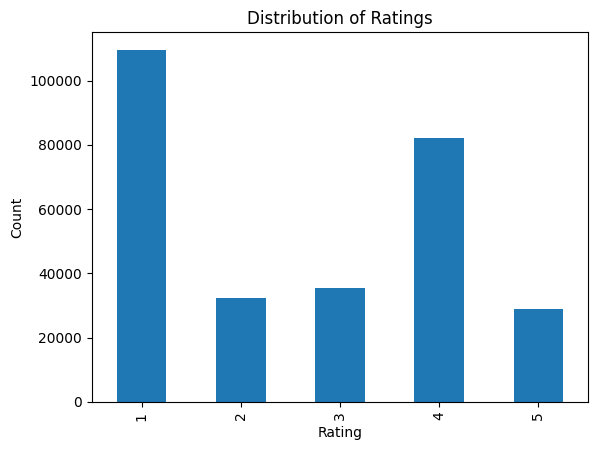

In [ ]:
import matplotlib.pyplot as plt

train['rating'].value_counts().sort_index().plot(kind='bar')
rating_counts = train['rating'].value_counts().sort_index()
rating_percent = (rating_counts / len(train)) * 100

# Combine side by side
result = pd.concat([rating_counts, rating_percent], axis=1)
result.columns = ['Count', 'Percentage(%)']

print(result)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**Findings:**

The distribution of ratings is clearly imbalanced. Rating 1 constitutes the largest proportion of the dataset at 38.05%, followed by rating 4 at 28.50%. In contrast, ratings 2 (11.19%), 3 (12.27%), and 5 (10.00%) are significantly underrepresented.

To quantify the imbalance:

* The majority class (rating 1) is nearly 3.8× larger than the minority class (rating 5).
* Combined, ratings 1 and 4 account for ~66.5% of the dataset, indicating dominance of just two classes.
* The remaining three classes together make up only ~33.5%, showing skewed representation.

This uneven distribution can bias machine learning models toward predicting majority classes, leading to poorer performance on underrepresented ratings.

**Compute average review length per rating**

In [ ]:
train['text_length'] = train['text'].apply(len)

avg_length = train.groupby('rating')['text_length'].mean()
print(avg_length)

rating
1    435.034184
2    407.232168
3    250.990800
4    179.256759
5    225.897535
Name: text_length, dtype: float64


**Findings:**

Lower ratings (1 and 2) are associated with substantially longer reviews, suggesting that dissatisfied users tend to provide detailed explanations of their negative experiences. In contrast, higher ratings (4 and 5) have shorter reviews, indicating that satisfied users are less likely to elaborate extensively. Neutral reviews (rating 3) fall in between, both in sentiment and length.

**Review Length Analysis**

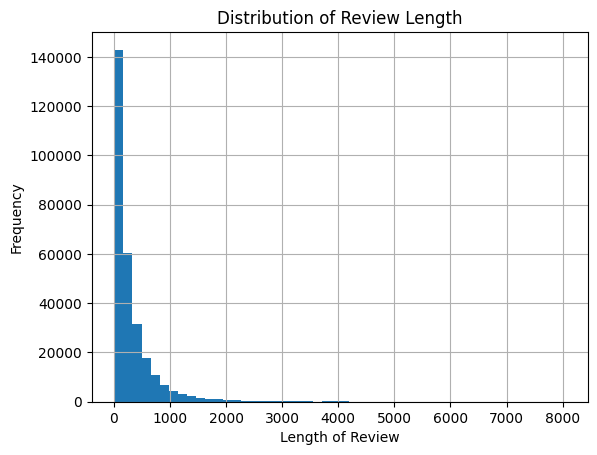

In [ ]:
train['text_length'] = train['text'].apply(len)

train['text_length'].hist(bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Length of Review")
plt.ylabel("Frequency")
plt.show()

**Findings:**

The distribution of review length is highly right-skewed, with the majority of reviews being short, typically under 300 characters. However, there are several extreme outliers, with some reviews exceeding 8000 characters. This indicates that while most users provide concise feedback, a small number of users write very detailed reviews.

**Review Length vs Rating**

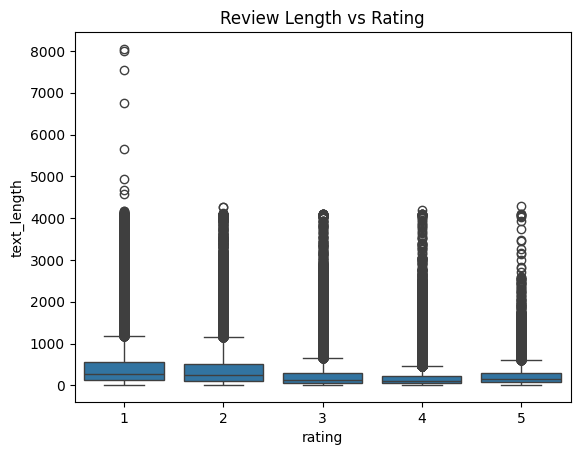

In [ ]:
import seaborn as sns

sns.boxplot(x='rating', y='text_length', data=train)
plt.title("Review Length vs Rating")
plt.show()

**Findings:**

The relationship between review length and rating shows that all rating categories exhibit similar distributions with significant overlap. Although lower-rated reviews (1–2 stars) tend to be slightly longer and contain more extreme outliers, the difference is not substantial. Higher-rated reviews (4–5 stars) are generally shorter and more concise.

**Review Length Distribution by Rating**

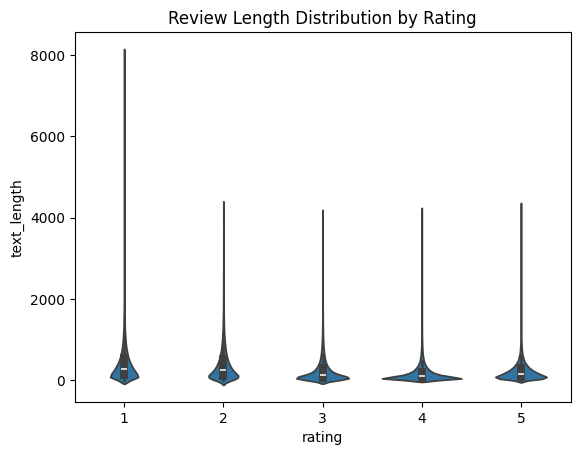

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x='rating', y='text_length', data=train)
plt.title("Review Length Distribution by Rating")
plt.show()

**Findings:**

The violin plot shows that review length distributions are highly similar across all rating categories. Most reviews are short, with a high concentration below 300 characters, while a small number of very long reviews appear as outliers. Lower-rated reviews (1–2 stars) tend to have slightly wider distributions, suggesting more detailed feedback, whereas higher-rated reviews (4–5 stars) are more concise.

**Unique words**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(train['text'])

print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 120074


**Findings:**

The dataset contains a vocabulary of 120,074 unique words, indicating a high level of linguistic diversity and richness in the text data.

**Most Common Non-Informative Words**

In [ ]:
from collections import Counter
import re

def get_words(text):
    return re.findall(r'\w+', text.lower())

all_words = []
for t in train['text']:
    all_words.extend(get_words(t))

common_words = Counter(all_words).most_common(20)
print(common_words)

[('the', 693413), ('i', 542848), ('and', 541470), ('to', 517520), ('a', 377624), ('was', 241969), ('they', 225770), ('my', 216320), ('for', 205720), ('of', 200527), ('it', 196757), ('in', 188040), ('is', 179159), ('that', 165666), ('not', 145650), ('this', 135189), ('you', 134882), ('with', 132300), ('t', 130558), ('me', 124432)]


The results show that the top occurring words include “the”, “I”, “and”, “to”, “a”, etc.

**Findings:**

* These words are stopwords, which are common in English language text
They appear with very high frequency but do not contribute meaningful information for sentiment prediction

**Conclusion:**

* Stopwords should be removed during preprocessing
This will help improve model performance by focusing on informative words

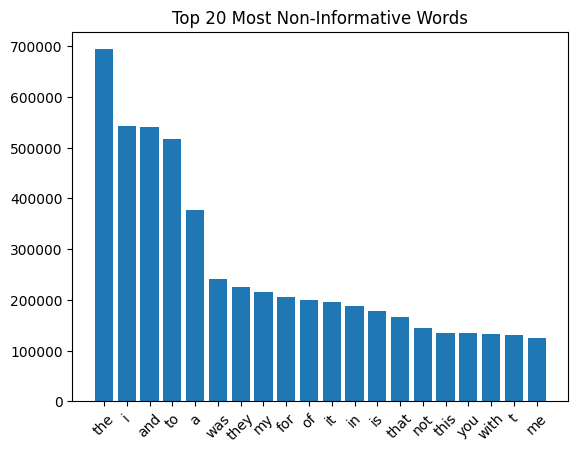

In [ ]:
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Non-Informative Words")
plt.show()

**Findings:**

The most frequent words in the dataset are common stopwords, such as “the”, “I”, “and”, “to”, “a”. These words dominate the dataset with extremely high counts (e.g., “the” ≈ 700,000 occurrences), showing they appear in almost every review.

**Most Common Informative Words**

In [ ]:
from collections import Counter
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_words(text):
    words = re.findall(r'\w+', text.lower())
    # Remove stopwords and short words
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return words

all_words = []
for t in train['text']:
    all_words.extend(get_words(t))

common_words = Counter(all_words).most_common(20)
print(common_words)

[('time', 59739), ('service', 54589), ('place', 51778), ('good', 49556), ('just', 47923), ('great', 44064), ('like', 41247), ('don', 38403), ('told', 36782), ('did', 36225), ('staff', 34700), ('people', 32877), ('work', 31944), ('said', 31880), ('nice', 28749), ('called', 28081), ('didn', 27360), ('got', 27359), ('customer', 25440), ('went', 25157)]


The results show meaningful words such as “time”, “service”, “place”, “good”, “great”, and “staff”.

**Findings:**

* These words are directly related to customer experience and sentiment
Positive sentiment words (e.g., good, great, nice) appear frequently
Service-related terms (e.g., staff, customer, service) dominate the dataset

**Conclusion:**

* The dataset contains rich and informative textual features
It is well-suited for sentiment analysis and classification tasks

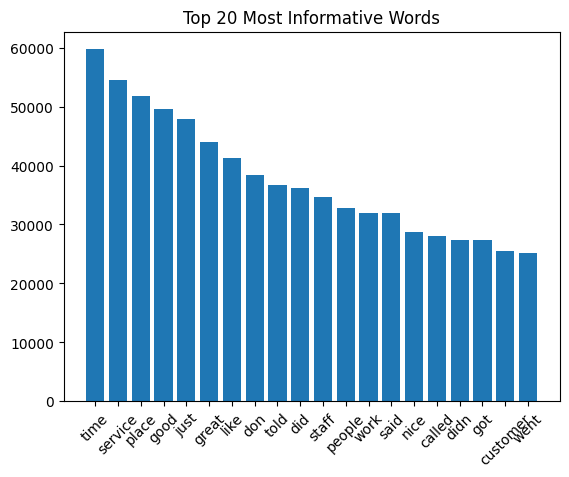

In [ ]:
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Informative Words")
plt.show()

**Findings:**

After removing stopwords, the most frequent words are now meaningful and context-rich, such as “time”, “service”, “place”, “good”, “great”.
These words are directly related to customer experience and sentiment, making them highly useful for analysis.

**Word Cloud**

In [ ]:
!pip install wordcloud

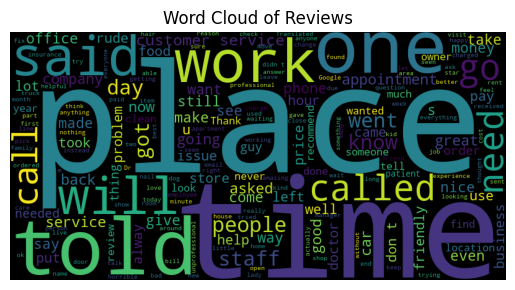

In [ ]:
from wordcloud import WordCloud

text_all = " ".join(train['text'])

wc = WordCloud(width=800, height=400).generate(text_all)

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()

A word cloud was generated to visually represent the most frequent words in the dataset. The visualization highlights prominent terms such as “service”, “time”, “good”, “staff”, and “customer”.

**Findings:**

* The most dominant words are related to customer experience and service quality
* Both positive sentiment words (e.g., good, great, nice) and interaction-related terms (e.g., told, called, said) are highly visible.
* This confirms that the dataset contains rich and meaningful textual information.

### **Key Insights from Data Exploration**
* Class imbalance present (ratings 1 and 4 dominate) → use stratified sampling and F1-score / weighted metrics for evaluation
* Review lengths are mostly short (right-skewed distribution) → unigrams and bigrams (1–2 n-grams) should work well
* Stopwords are frequent in raw text → apply stopword removal during preprocessing
* Large vocabulary (~120K unique words) → use TF-IDF to manage high dimensionality and highlight important terms
* Strong sentiment words present (e.g., “good”, “bad”, “service”) → supports effectiveness of statistical text features
* Review length weakly correlated with rating → exclude text length as a primary feature
* Meaningful word patterns exist → consider advanced models (LSTM / Transformers) for improved performance

# **2. Text Processing and Normalization**

Prepare raw text data for machine learning by cleaning, standardizing, and transforming it into a meaningful representation, while evaluating different preprocessing techniques and their impact.

You should experiment with things like:

* Lowercasing
* Removing punctuation
* Tokenization
* Removing stopwords
* Stemming
* Lemmatization

**Basic Text Cleaning**

In [ ]:
import re

# Cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Apply to both train and test
train['clean_text'] = train['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)

# Print results
print(train['clean_text'].head())
print(test['clean_text'].head())

0    this place is terrible the people in charge ar...
1    terrible service and they are saying that i ne...
2    absolutely terrible company  they sent me to c...
3    to find it either park in front of the tuesday...
4    mall location used their services for sedan ni...
Name: clean_text, dtype: object
0    every time ive been hear theyve done a great j...
1    if u like calm and layed back  without the ste...
2    i would give this place  if i could my experie...
3    had some problems viewing a place and was not ...
4    the staff at this place is very rude they do n...
Name: clean_text, dtype: object


**Explanation**
* Converts all text to lowercase → ensures consistency

  * “Good” = “good”
  
* Removes punctuation and numbers → reduces noise
* Given this dataset (customer reviews), punctuation is less critical than word meaning, so cleaning improves model performance.

**Contraction Handling**

In [ ]:
# Function to expand contractions
def expand_contractions(text):
    text = text.replace("n't", " not")
    text = text.replace("'re", " are")
    text = text.replace("'s", " is")
    text = text.replace("'ll", " will")
    text = text.replace("'ve", " have")
    text = text.replace("'d", " would")
    return text

# Apply to both train and test
train['text_expanded'] = train['clean_text'].apply(expand_contractions)
test['text_expanded'] = test['clean_text'].apply(expand_contractions)

# Preview
print(train['text_expanded'].head())
print(test['text_expanded'].head())

0    this place is terrible the people in charge ar...
1    terrible service and they are saying that i ne...
2    absolutely terrible company  they sent me to c...
3    to find it either park in front of the tuesday...
4    mall location used their services for sedan ni...
Name: text_expanded, dtype: object
0    every time ive been hear theyve done a great j...
1    if u like calm and layed back  without the ste...
2    i would give this place  if i could my experie...
3    had some problems viewing a place and was not ...
4    the staff at this place is very rude they do n...
Name: text_expanded, dtype: object


**Explanation**

Contraction handling expands shortened word forms into their full versions. For example:

* “don’t” → “do not”
* “you’re” → “you are”

This makes the text more explicit and easier for models to interpret.

**Removing Punctuation and Special Characters**

In [ ]:
import re

# Remove punctuation and special characters
train['clean_text'] = train['text_expanded'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

test['clean_text'] = test['text_expanded'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

# Preview
print(train['clean_text'].head())
print(test['clean_text'].head())

0    this place is terrible the people in charge ar...
1    terrible service and they are saying that i ne...
2    absolutely terrible company  they sent me to c...
3    to find it either park in front of the tuesday...
4    mall location used their services for sedan ni...
Name: clean_text, dtype: object
0    every time ive been hear theyve done a great j...
1    if u like calm and layed back  without the ste...
2    i would give this place  if i could my experie...
3    had some problems viewing a place and was not ...
4    the staff at this place is very rude they do n...
Name: clean_text, dtype: object


**Explanation**

This step removes punctuation, numbers, and special characters using a regular expression, retaining only alphabetic characters and spaces. This simplifies the text and ensures consistency across the dataset.

**Tokenization**

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenize both datasets
train['tokens'] = train['clean_text'].apply(word_tokenize)
test['tokens'] = test['clean_text'].apply(word_tokenize)

# Print sample
print(train['tokens'].head())
print(test['tokens'].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


0    [this, place, is, terrible, the, people, in, c...
1    [terrible, service, and, they, are, saying, th...
2    [absolutely, terrible, company, they, sent, me...
3    [to, find, it, either, park, in, front, of, th...
4    [mall, location, used, their, services, for, s...
Name: tokens, dtype: object
0    [every, time, ive, been, hear, theyve, done, a...
1    [if, u, like, calm, and, layed, back, without,...
2    [i, would, give, this, place, if, i, could, my...
3    [had, some, problems, viewing, a, place, and, ...
4    [the, staff, at, this, place, is, very, rude, ...
Name: tokens, dtype: object


**Explanation**
* Splits text into individual words (tokens)
* Example:

  * "great service" → ["great", "service"]

* Tokenization is essential since machine learning models cannot process raw text directly.

**NLTK tokenization uses:**

* punkt → tokenizer model
* punkt_tab → language tables (new requirement in recent NLTK versions)

**Stopword Removal**

In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Remove stopwords for train
train['tokens_no_stop'] = train['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

# Remove stopwords for test
test['tokens_no_stop'] = test['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

print(train['tokens_no_stop'].head())
print(test['tokens_no_stop'].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    [place, terrible, people, charge, worst, part,...
1    [terrible, service, saying, never, used, servi...
2    [absolutely, terrible, company, sent, collecti...
3    [find, either, park, front, tuesday, morning, ...
4    [mall, location, used, services, sedan, nice, ...
Name: tokens_no_stop, dtype: object
0    [every, time, ive, hear, theyve, done, great, ...
1    [u, like, calm, layed, back, without, stereoty...
2    [would, give, place, could, experience, today,...
3    [problems, viewing, place, impressed, lack, re...
4    [staff, place, rude, return, phone, calls, ass...
Name: tokens_no_stop, dtype: object


**Explanation**
* Removes common words like: the, is, and, to
* Keeps only meaningful words
* EDA showed stopwords dominate the dataset → removing them improves feature quality. However, care should be taken with words like "not", which affect sentiment.

**Stemming**

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# Stemming for train
train['stemmed'] = train['tokens_no_stop'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

# Stemming for test
test['stemmed'] = test['tokens_no_stop'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

print(train['stemmed'].head())
print(test['stemmed'].head())

0    [place, terribl, peopl, charg, worst, part, fa...
1    [terribl, servic, say, never, use, servic, lie...
2    [absolut, terribl, compani, sent, collect, wit...
3    [find, either, park, front, tuesday, morn, mal...
4    [mall, locat, use, servic, sedan, nice, perhap...
Name: stemmed, dtype: object
0    [everi, time, ive, hear, theyv, done, great, j...
1    [u, like, calm, lay, back, without, stereotyp,...
2    [would, give, place, could, experi, today, ble...
3    [problem, view, place, impress, lack, respons,...
4    [staff, place, rude, return, phone, call, assi...
Name: stemmed, dtype: object


**Explanation**
* Reduces words to root form:
  * “running” → “run”
  * “service” → “servic”
* Useful for reducing dimensionality, but may distort meaning → not ideal for interpretability.

**Lemmatization**

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    return wordnet.NOUN

# Lemmatize train tokens
train['lemmatized'] = train['tokens_no_stop'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

# Lemmatize test tokens
test['lemmatized'] = test['tokens_no_stop'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

print(train['lemmatized'].head())
print(test['lemmatized'].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    [place, terrible, people, charge, worst, part,...
1    [terrible, service, saying, never, used, servi...
2    [absolutely, terrible, company, sent, collecti...
3    [find, either, park, front, tuesday, morning, ...
4    [mall, location, used, service, sedan, nice, p...
Name: lemmatized, dtype: object
0    [every, time, ive, hear, theyve, done, great, ...
1    [u, like, calm, layed, back, without, stereoty...
2    [would, give, place, could, experience, today,...
3    [problem, viewing, place, impressed, lack, res...
4    [staff, place, rude, return, phone, call, assi...
Name: lemmatized, dtype: object


**Explanation**
* Converts words to meaningful base forms:
  * “running” → “run”
  * “better” → “good” (in advanced cases)
* For this dataset (sentiment analysis), preserving meaning is critical → lemmatization is preferred over stemming.

In [ ]:
train['processed_text'] = train['lemmatized'].apply(lambda x: " ".join(x))
test['processed_text'] = test['lemmatized'].apply(lambda x: " ".join(x))

print(train[['text','processed_text']].head())
print(test[['text','processed_text']].head())

                                                text  \
0  This place is TERRIBLE; the people in charge a...   
1  Terrible Service! And they are saying that I n...   
2  Absolutely terrible company.  They sent me to ...   
3  To find it, either park in front of the Tuesda...   
4  Mall location. Used their services for sedan. ...   

                                      processed_text  
0  place terrible people charge worst part far ye...  
1  terrible service saying never used service lie...  
2  absolutely terrible company sent collection wi...  
3  find either park front tuesday morning mall en...  
4  mall location used service sedan nice perhaps ...  
                                                text  \
0  Every time I’ve been hear they’ve done a great...   
1  if u like calm and layed back  without the ste...   
2  I would give this place 0 if I could. My exper...   
3  Had some problems viewing a place and was not ...   
4  The staff at this place is very rude! They do ... 

**Final Processed Text Representation**

After applying all preprocessing steps, including cleaning, tokenization, stopword removal, and lemmatization, the text was reconstructed into a final processed format.

**Findings:**

* The processed text is significantly cleaner and more concise
* Non-informative words and punctuation have been removed
* Important sentiment-related words such as “terrible”, “service”, and “rude” are preserved
* Vocabulary size is reduced while maintaining semantic meaning

**Example Comparison:** Stemming vs Lemmatization

In [ ]:
for i in range(2):
    print("Original:", train['tokens_no_stop'].iloc[i])
    print("Stemmed :", train['stemmed'].iloc[i])
    print("Lemmatized:", train['lemmatized'].iloc[i])
    print("-" * 50)

Original: ['place', 'terrible', 'people', 'charge', 'worst', 'part', 'far', 'yeah', 'place', 'beautiful', 'inside', 'people', 'running', 'director', 'nice', 'first', 'truly', 'careless', 'family', 'honestly', 'gave', 'two', 'star', 'dedicated', 'employees', 'really', 'enjoy', 'dedication', 'bring', 'table', 'reasons', 'want', 'bring', 'children', 'however', 'suggestfor', 'place', 'become', 'better', 'experience', 'reevaluate', 'director', 'assistant', 'director']
Stemmed : ['place', 'terribl', 'peopl', 'charg', 'worst', 'part', 'far', 'yeah', 'place', 'beauti', 'insid', 'peopl', 'run', 'director', 'nice', 'first', 'truli', 'careless', 'famili', 'honestli', 'gave', 'two', 'star', 'dedic', 'employe', 'realli', 'enjoy', 'dedic', 'bring', 'tabl', 'reason', 'want', 'bring', 'children', 'howev', 'suggestfor', 'place', 'becom', 'better', 'experi', 'reevalu', 'director', 'assist', 'director']
Lemmatized: ['place', 'terrible', 'people', 'charge', 'worst', 'part', 'far', 'yeah', 'place', 'beauti

**Key insigts of Text Processing and Normalization:**

* Lowercasing ensures consistent word representation
* Contraction handling preserves negation meaning
* Punctuation removal reduces noise
* Tokenization structures the text
* Stopword removal improves efficiency while keeping not/no
* Stemming reduces vocabulary but may distort meaning
* Lemmatization preserves meaning → **best choice for sentiment analysis**

**Lowercasing + Contraction Handling + Punctuation Removal + Tokenization + Stopword Removal + Lemmatization** together create a clean, consistent, and meaningful text representation.

# **Step 3 — Vector Space Model & Feature Representation**

Convert text into numerical feature vectors so machine learning models can use them.

You should experiment with:

* Binary Bag of Words
* Count (Frequency) Bag of Words
* TF-IDF
* N-grams (unigram, bigram, trigram)
* Word-Embeddings: Word2Vec

**Train:**
clean → preprocess → fit vectorizer → transform

**Test:**
clean → preprocess → transform only


* fit()= Learn from the data
* transform()= Convert text into numbers using what was learned in fit


**Bag of Words (Count Vectorizer)**

The Bag of Words (BoW) model converts text into numerical features by counting how many times each word appears in a document.

In this approach:

* Each unique word in the dataset becomes a feature (column)
* Each review becomes a vector (row)
* The values in the matrix indicate the frequency of each word in that review

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

# Fit on train, transform train
X_train_count = count_vectorizer.fit_transform(train['processed_text'])

# Transform test using same vectorizer
X_test_count = count_vectorizer.transform(test['processed_text'])

print(X_train_count.shape)
print(X_test_count.shape)

(288000, 138624)
(72000, 138624)


**Explanation:**

Both training and test datasets have the same number of columns, meaning they share the same vocabulary learned from the training data.

The Count Vectorizer transforms the processed text into a numerical matrix where each feature corresponds to a word, and each value represents how frequently that word appears in a given review.

**Binary Bag of Words**

The Binary Bag of Words model represents text data by indicating whether a word is present or not in a document.

In this approach:

* Each unique word becomes a feature (column)
* Each review becomes a vector (row)
* The value is:
  * 1 → word appears in the review
  * 0 → word does not appear

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

binary_vectorizer = CountVectorizer(binary=True)

# Fit on train
X_train_binary = binary_vectorizer.fit_transform(train['processed_text'])

# Transform test
X_test_binary = binary_vectorizer.transform(test['processed_text'])

print(X_train_binary.shape)
print(X_test_binary.shape)

(288000, 138624)
(72000, 138624)


**Explanation:**

The number of features is the same as the Count Vectorizer because both use the same vocabulary learned from the training data.

The Binary Bag of Words model converts text into a numerical format where each feature indicates the presence or absence of a word in a review, rather than its frequency.

**Binary vs Count**

* Count Vectorizer (BoW) uses word frequency → captures how often a word appears
* Binary Vectorizer uses presence (0/1) → only checks if a word exists

While Count Vectorizer captures word importance through frequency, Binary Bag of Words simplifies representation by focusing on word presence. For this dataset, Binary features may help reduce bias from longer reviews, whereas Count features can better capture sentiment intensity. Therefore, both approaches will be evaluated to determine which yields better model performance.

**TF-IDF**

TF-IDF is a text representation technique that converts text into numerical features by considering both the frequency of a word in a document and its importance across the entire dataset.

In this approach:

* Each unique word becomes a feature (column)
* Each review becomes a vector (row)
* The value represents the importance score of a word, not just its frequency
  * TF (Term Frequency): how often a word appears in a document
  * IDF (Inverse Document Frequency): reduces the weight of words that appear frequently across many documents

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

# Fit on train
X_train_tfidf = tfidf_vectorizer.fit_transform(train['processed_text'])

# Transform test
X_test_tfidf = tfidf_vectorizer.transform(test['processed_text'])

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(288000, 138624)
(72000, 138624)


**Explanation:**

Both training and test datasets share the same feature space, as the vectorizer is fitted only on the training data and then applied to the test data.

TF-IDF transforms the processed text into a numerical matrix where each value reflects how important a word is in a review relative to the entire dataset, giving less importance to very common words and more importance to distinctive words.

**N-gram Features**

N-gram features extend basic text representation by considering sequences of words instead of individual words. This helps capture context and relationships between word

**Unigram (1-word features)**

In [ ]:
tfidf_uni = TfidfVectorizer(ngram_range=(1,1))

X_train_uni = tfidf_uni.fit_transform(train['processed_text'])
X_test_uni = tfidf_uni.transform(test['processed_text'])

print(X_train_uni.shape)
print(X_test_uni.shape)

(288000, 138624)
(72000, 138624)


**Explanation**
* Each feature represents a single word
* Example:
  * "good service" → "good", "service"
* Vocabulary size is Same as standard TF-IDF Only captures individual word information

**Bigram (2-word features)**

In [ ]:
tfidf_bigram = TfidfVectorizer(ngram_range=(2,2))

X_train_bigram = tfidf_bigram.fit_transform(train['processed_text'])
X_test_bigram = tfidf_bigram.transform(test['processed_text'])

print(X_train_bigram.shape)
print(X_test_bigram.shape)

(288000, 2888213)
(72000, 2888213)


**Explanation**
* Each feature represents a pair of consecutive words
* Example:
  * "not good" → "not good"
  * "very bad" → "very bad"
* Vocabulary size increased to 2,888,213 and it was Much larger feature space than unigram.
* Captures relationships between words

**Trigram (3-word features)**

In [ ]:
tfidf_trigram = TfidfVectorizer(ngram_range=(3,3))

X_train_trigram = tfidf_trigram.fit_transform(train['processed_text'])
X_test_trigram = tfidf_trigram.transform(test['processed_text'])

print(X_train_trigram.shape)
print(X_test_trigram.shape)

(288000, 6671606)
(72000, 6671606)


**Explanation**
* Each feature represents a sequence of three words
* Example:
  * "very bad service"
* Vocabulary size increased to 6,671,606 and it was Extremely high dimensional feature space
* Captures more detailed context

As the n-gram size increases, the model captures more context, but the number of features grows rapidly, leading to a much larger and more complex representation.

**TF-IDF Vectorization + n(1,2)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_uni_bigram = TfidfVectorizer(ngram_range=(1,2))

X_train_uni_bigram = tfidf_uni_bigram.fit_transform(train['processed_text'])
X_test_uni_bigram = tfidf_uni_bigram.transform(test['processed_text'])

print(X_train_uni_bigram.shape)
print(X_test_uni_bigram.shape)

(288000, 3026837)
(72000, 3026837)


The text data was transformed into numerical vectors using TF-IDF vectorization. Unigram and bigram features were used to capture both individual words and short phrases.

**Word Embeddings (Word2Vec)**

Word2Vec is a technique that converts words into dense numerical vectors that capture semantic meaning. Unlike Bag of Words or TF-IDF, it represents words based on their context and relationships.

**It Works**
* The model is trained on the training text data
* It learns word representations such that:
* Words used in similar contexts have similar vectors
* Each word is represented as a fixed-length vector

**Sentence Representation**
* Each review is split into tokens (words)
* For each word:
  * If the word exists in the model, its vector is retrieved
* The final review vector is computed by:
  * Averaging all word vectors
* This results in a single dense vector representation for each review

In [ ]:
pip install gensim

Create Tokens (Train + Test)

In [ ]:
train['tokens'] = train['processed_text'].apply(lambda x: x.split())
test['tokens'] = test['processed_text'].apply(lambda x: x.split())

Train Word2Vec Model (Train Only)

In [ ]:
from gensim.models import Word2Vec
import numpy as np

sentences = train['tokens']

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Function to Convert Sentence → Vector

In [ ]:
def sentence_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

Convert Train and Test to Vectors

In [ ]:
train['w2v_vector'] = train['tokens'].apply(lambda x: sentence_vector(x, w2v_model))
test['w2v_vector'] = test['tokens'].apply(lambda x: sentence_vector(x, w2v_model))

Convert to Matrix

In [ ]:
X_train_w2v = np.vstack(train['w2v_vector'].values)
X_test_w2v = np.vstack(test['w2v_vector'].values)

print("Word2Vec Train Shape:", X_train_w2v.shape)
print("Word2Vec Test Shape:", X_test_w2v.shape)

Word2Vec Train Shape: (288000, 100)
Word2Vec Test Shape: (72000, 100)


**Explanation:**
* Unlike previous methods:
  * Feature size is fixed (100 features)
  * Does not depend on vocabulary size
* Each review is represented as a dense vector instead of a sparse matrix

Word2Vec converts each review into a dense numerical vector by capturing semantic relationships between words, where similar words have similar vector representations.

**Example:** Check Word Embeddings

In [ ]:
print(w2v_model.wv['good'])

[ 2.93298149e+00 -8.30736160e-01  1.55493414e+00  2.36366129e+00
 -4.97256607e-01  4.19376224e-01 -1.19140960e-01 -1.24512649e+00
 -1.11208923e-01  4.01226044e-01 -3.42791617e-01  1.45461798e+00
  6.53524280e-01 -9.52271581e-01  1.74610913e+00 -7.69734919e-01
 -8.17618966e-01  6.73830271e-01  1.80406916e+00  3.87240499e-01
  1.25861490e+00  1.61587286e+00  1.54890823e+00 -2.14105964e+00
  9.46660459e-01 -1.88902199e-01  5.42545140e-01 -4.67568487e-01
  1.05790925e+00 -3.48163056e+00  6.74770330e-04 -4.12255883e-01
 -4.31531489e-01  4.69136285e-03  1.69369590e+00 -2.80432731e-01
 -3.03876102e-01  2.51031786e-01 -4.80836004e-01 -8.33504558e-01
  5.84552407e-01  8.36696386e-01 -2.10200500e+00 -2.18907905e+00
 -1.06060326e+00  8.28484714e-01 -2.50777555e+00 -5.16546130e-01
 -1.20425963e+00 -9.06083167e-01 -1.83577108e+00  4.99267966e-01
 -6.96325898e-01 -4.58248436e-01  1.01961968e-02 -1.42435002e+00
 -4.87423897e-01 -1.57801557e+00  3.93062532e-02 -1.65701830e+00
 -1.37976289e+00 -1.48514

**Key insigts of Feature Representation:**

Several feature representation techniques were explored, including Bag of Words, Binary Bag of Words, TF-IDF, n-grams, and Word2Vec. Trigram features resulted in extremely large feature spaces and high computational cost, making them impractical.

TF-IDF unigram, TF-IDF bigram, and Word2Vec were selected for further experiments. TF-IDF captures term importance, bigrams capture contextual word relationships, and Word2Vec provides dense semantic representations, making them suitable for effective text classification.

# **4. Model training, selection and hyperparameter tuning and evaluation**

In this step, multiple classification models were trained and evaluated for the sentiment classification task. Based on findings from Step 2 and Step 3, lemmatized text with TF-IDF (unigram + bigram) and Word2Vec embeddings were selected as feature representations.

Three models were implemented:

* Logistic Regression
* Naive Bayes
* Support Vector Machine (SVM)

Hyperparameter tuning was performed using cross-validation (GridSearchCV) to optimize model performance.

Prepare Data

In [ ]:
X_train = train['processed_text']
y_train = train['rating']

X_test = test['processed_text']
y_test = test['rating']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (288000,)
Test size: (72000,)


The dataset was divided into:

* Input features (X): processed review text
* Target labels (y): rating values

Preprocessed text from Step 2 was used as input for all models

### **LR Model + All Feature + Hyperparameter Tuning**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {'C': [0.1, 1, 5]}

Hyperparameter tuning was performed using GridSearchCV with 3-fold cross-validation to find the optimal value of the regularization parameter C.

**BLOCK 1: BoW**

BoW Results: ['BoW', 0.1, 0.6445, 0.6487]
BoW
               precision    recall  f1-score   support

           1       0.74      0.89      0.81     27395
           2       0.37      0.11      0.17      8055
           3       0.38      0.15      0.22      8832
           4       0.60      0.82      0.69     20518
           5       0.69      0.45      0.54      7200

    accuracy                           0.65     72000
   macro avg       0.55      0.48      0.49     72000
weighted avg       0.61      0.65      0.60     72000



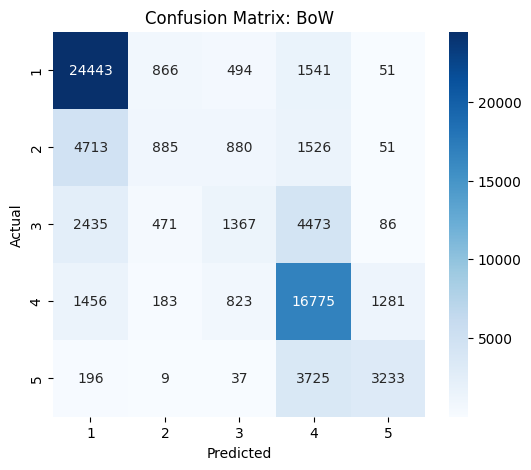

In [ ]:
grid_lr_bow = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr_bow.fit(X_train_count, y_train)

best_model_bow = grid_lr_bow.best_estimator_

y_pred_bow = best_model_bow.predict(X_test_count)

bow_result = [
    "BoW",
    grid_lr_bow.best_params_['C'],
    round(grid_lr_bow.best_score_, 4),
    round(accuracy_score(y_test, y_pred_bow), 4)
]
print("BoW Results:", bow_result)

print("BoW\n", classification_report(y_test, y_pred_bow))

labels = [1, 2, 3, 4, 5]

# Confusion Matrix for BoW only
cm = confusion_matrix(y_test, y_pred_bow, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: BoW")
plt.show()

BLOCK 2: TF-IDF (1,1)

TF-IDF (1,1) Results: ['TF-IDF (1,1)', 1, 0.6498, 0.6539]
TF-IDF (1,1)
               precision    recall  f1-score   support

           1       0.73      0.91      0.81     27395
           2       0.38      0.12      0.18      8055
           3       0.39      0.18      0.25      8832
           4       0.62      0.78      0.69     20518
           5       0.66      0.49      0.57      7200

    accuracy                           0.65     72000
   macro avg       0.56      0.50      0.50     72000
weighted avg       0.61      0.65      0.61     72000



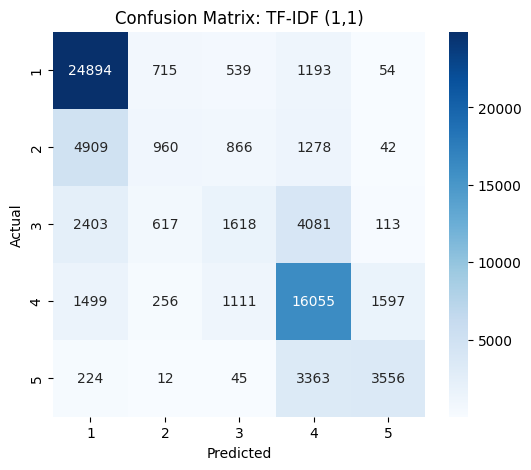

In [ ]:
grid_lr_uni = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr_uni.fit(X_train_uni, y_train)

best_model_uni = grid_lr_uni.best_estimator_

y_pred_uni = best_model_uni.predict(X_test_uni)

uni_result = [
    "TF-IDF (1,1)",
    grid_lr_uni.best_params_['C'],
    round(grid_lr_uni.best_score_, 4),
    round(accuracy_score(y_test, y_pred_uni), 4)
]

print("TF-IDF (1,1) Results:", uni_result)

print("TF-IDF (1,1)\n", classification_report(y_test, y_pred_uni))

labels = [1, 2, 3, 4, 5]

# Confusion Matrix for TF-IDF (1,1)
cm = confusion_matrix(y_test, y_pred_uni, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: TF-IDF (1,1)")
plt.show()

BLOCK 3: TF-IDF (2,2)

TF-IDF (2,2) Results: ['TF-IDF (2,2)', 5, 0.6162, 0.6218]
TF-IDF (2,2)
               precision    recall  f1-score   support

           1       0.70      0.89      0.78     27395
           2       0.34      0.10      0.15      8055
           3       0.36      0.15      0.21      8832
           4       0.58      0.75      0.65     20518
           5       0.63      0.42      0.50      7200

    accuracy                           0.62     72000
   macro avg       0.52      0.46      0.46     72000
weighted avg       0.58      0.62      0.58     72000



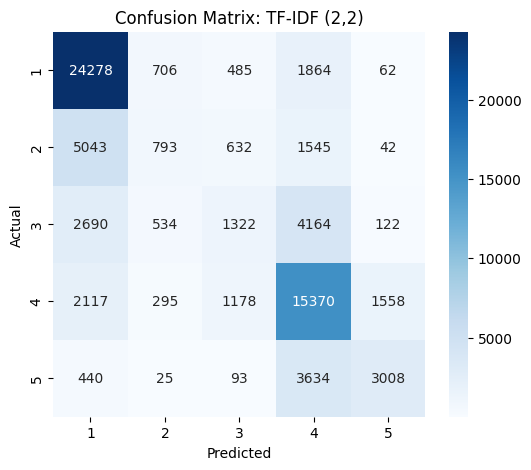

In [ ]:
grid_lr_bigram = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='saga'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr_bigram.fit(X_train_bigram, y_train)

best_model_bigram = grid_lr_bigram.best_estimator_

y_pred_bigram = best_model_bigram.predict(X_test_bigram)

bigram_result = [
    "TF-IDF (2,2)",
    grid_lr_bigram.best_params_['C'],
    round(grid_lr_bigram.best_score_, 4),
    round(accuracy_score(y_test, y_pred_bigram), 4)
]

print("TF-IDF (2,2) Results:", bigram_result)

print("TF-IDF (2,2)\n", classification_report(y_test, y_pred_bigram))

labels = [1, 2, 3, 4, 5]

# Confusion Matrix for TF-IDF (2,2)
cm = confusion_matrix(y_test, y_pred_bigram, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: TF-IDF (2,2)")
plt.show()

BLOCK 4: TF-IDF (1,2)

TF-IDF (1,2) Results: ['TF-IDF (1,2)', 1, 0.6549, 0.6627]
TF-IDF (1,2)
               precision    recall  f1-score   support

           1       0.73      0.92      0.82     27395
           2       0.40      0.12      0.19      8055
           3       0.42      0.18      0.25      8832
           4       0.63      0.78      0.70     20518
           5       0.65      0.53      0.58      7200

    accuracy                           0.66     72000
   macro avg       0.57      0.51      0.51     72000
weighted avg       0.62      0.66      0.62     72000



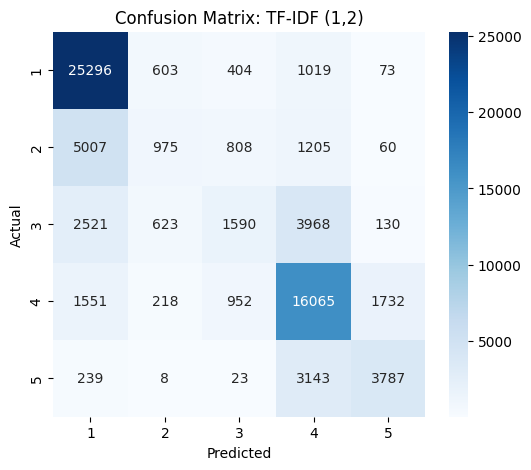

In [ ]:
grid_lr_12 = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='saga'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr_12.fit(X_train_uni_bigram, y_train)

best_model_12 = grid_lr_12.best_estimator_

y_pred_12 = best_model_12.predict(X_test_uni_bigram)

tfidf12_result = [
    "TF-IDF (1,2)",
    grid_lr_12.best_params_['C'],
    round(grid_lr_12.best_score_, 4),
    round(accuracy_score(y_test, y_pred_12), 4)
]

print("TF-IDF (1,2) Results:", tfidf12_result)

print("TF-IDF (1,2)\n", classification_report(y_test, y_pred_12))

labels = [1, 2, 3, 4, 5]

# Confusion Matrix for TF-IDF (1,2)
cm = confusion_matrix(y_test, y_pred_12, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: TF-IDF (1,2)")
plt.show()

BLOCK 5: Word2Vec

Word2Vec Results: ['Word2Vec', 5, 0.6235, 0.6249]
Word2Vec
               precision    recall  f1-score   support

           1       0.68      0.93      0.79     27395
           2       0.32      0.03      0.06      8055
           3       0.38      0.10      0.16      8832
           4       0.58      0.78      0.66     20518
           5       0.59      0.33      0.43      7200

    accuracy                           0.62     72000
   macro avg       0.51      0.43      0.42     72000
weighted avg       0.57      0.62      0.56     72000



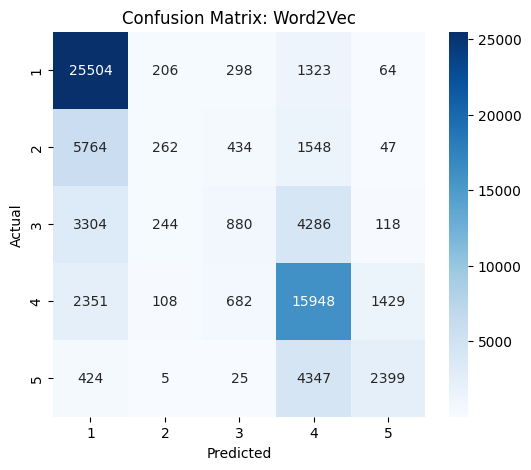

In [ ]:
grid_lr_w2v = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr_w2v.fit(X_train_w2v, y_train)

best_model_w2v = grid_lr_w2v.best_estimator_

y_pred_w2v = best_model_w2v.predict(X_test_w2v)

w2v_result = [
    "Word2Vec",
    grid_lr_w2v.best_params_['C'],
    round(grid_lr_w2v.best_score_, 4),
    round(accuracy_score(y_test, y_pred_w2v), 4)
]

print("Word2Vec Results:", w2v_result)

print("Word2Vec\n", classification_report(y_test, y_pred_w2v))

labels = [1, 2, 3, 4, 5]

# Confusion Matrix for Word2Vec
cm = confusion_matrix(y_test, y_pred_w2v, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Word2Vec")
plt.show()

FINAL TABLE (COMBINE RESULTS)

In [ ]:
import pandas as pd

results = [
    bow_result,
    uni_result,
    bigram_result,
    tfidf12_result,
    w2v_result
]

df = pd.DataFrame(results, columns=[
    "Feature", "Best C", "CV Accuracy", "Test Accuracy"
])

print("\nFinal Comparison Table:\n")
print(df.sort_values(by="Test Accuracy", ascending=False))


Final Comparison Table:

        Feature  Best C  CV Accuracy  Test Accuracy
3  TF-IDF (1,2)     1.0       0.6549         0.6627
1  TF-IDF (1,1)     1.0       0.6498         0.6539
0           BoW     0.1       0.6445         0.6487
4      Word2Vec     5.0       0.6235         0.6249
2  TF-IDF (2,2)     5.0       0.6162         0.6218


**Explanation:**

The Logistic Regression model was evaluated using different feature representations. Among all methods, TF-IDF (unigram + bigram) achieved the best performance with a test accuracy of 0.6627.

Logistic Regression was selected because it performs well on high-dimensional text data and works effectively with sparse features such as TF-IDF. It is also computationally efficient, easy to interpret, and provides stable performance across different feature representations.

Logistic Regression with TF-IDF (1,2) was selected as the best configuration due to its highest accuracy and ability to capture both word importance and contextual information.

### **Naive Bayes Model + All feature + Hypertuning**

BLOCK 1: BoW

In [ ]:
from sklearn.naive_bayes import MultinomialNB
param_grid = {'alpha': [0.1, 1, 5]}

BoW Results: ['BoW', 1, 0.6179, 0.622]
BoW
               precision    recall  f1-score   support

           1       0.70      0.88      0.78     27395
           2       0.30      0.11      0.16      8055
           3       0.30      0.10      0.15      8832
           4       0.60      0.74      0.66     20518
           5       0.60      0.52      0.56      7200

    accuracy                           0.62     72000
   macro avg       0.50      0.47      0.46     72000
weighted avg       0.57      0.62      0.58     72000


Classification Report (BoW):
              precision    recall  f1-score   support

           1       0.70      0.88      0.78     27395
           2       0.30      0.11      0.16      8055
           3       0.30      0.10      0.15      8832
           4       0.60      0.74      0.66     20518
           5       0.60      0.52      0.56      7200

    accuracy                           0.62     72000
   macro avg       0.50      0.47      0.46     72000
wei

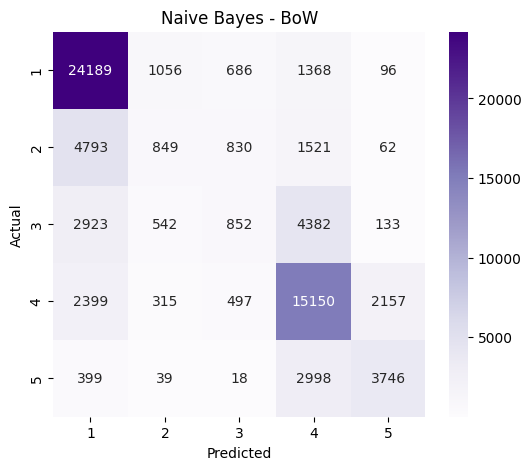

In [ ]:
grid_nb_bow = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb_bow.fit(X_train_count, y_train)

best_nb_bow = grid_nb_bow.best_estimator_

y_pred_bow = best_nb_bow.predict(X_test_count)

bow_result = [
    "BoW",
    grid_nb_bow.best_params_['alpha'],
    round(grid_nb_bow.best_score_, 4),
    round(accuracy_score(y_test, y_pred_bow), 4)
]

print("BoW Results:", bow_result)

print("BoW\n", classification_report(y_test, y_pred_bow))

print("\nClassification Report (BoW):")
print(classification_report(y_test, y_pred_bow))

cm = confusion_matrix(y_test, y_pred_bow, labels=[1,2,3,4,5])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])

plt.title("Naive Bayes - BoW")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

BLOCK 2: TF-IDF (1,1)

TF-IDF (1,1) Results: ['TF-IDF (1,1)', 0.1, 0.6081, 0.6135]
TF-IDF (1,1)
               precision    recall  f1-score   support

           1       0.65      0.93      0.76     27395
           2       0.30      0.02      0.04      8055
           3       0.32      0.06      0.10      8832
           4       0.58      0.76      0.66     20518
           5       0.67      0.33      0.44      7200

    accuracy                           0.61     72000
   macro avg       0.51      0.42      0.40     72000
weighted avg       0.55      0.61      0.54     72000



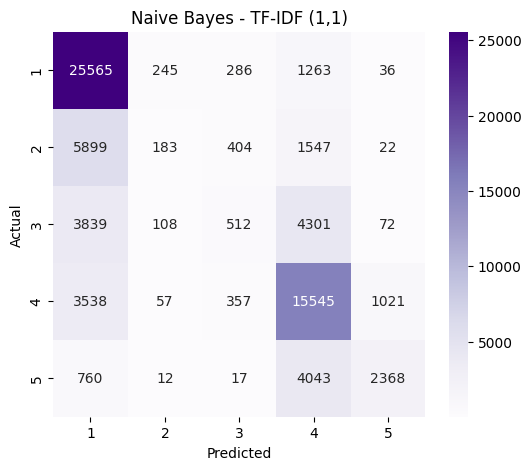

In [ ]:
grid_nb_uni = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb_uni.fit(X_train_uni, y_train)

best_nb_uni = grid_nb_uni.best_estimator_

y_pred_uni = best_nb_uni.predict(X_test_uni)

uni_result = [
    "TF-IDF (1,1)",
    grid_nb_uni.best_params_['alpha'],
    round(grid_nb_uni.best_score_, 4),
    round(accuracy_score(y_test, y_pred_uni), 4)
]

print("TF-IDF (1,1) Results:", uni_result)

print("TF-IDF (1,1)\n", classification_report(y_test, y_pred_uni))

cm = confusion_matrix(y_test, y_pred_uni, labels=[1,2,3,4,5])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])

plt.title("Naive Bayes - TF-IDF (1,1)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

BLOCK 3: TF-IDF (2,2)

TF-IDF (2,2) Results: ['TF-IDF (2,2)', 0.1, 0.6041, 0.6079]
TF-IDF (2,2)
               precision    recall  f1-score   support

           1       0.63      0.96      0.76     27395
           2       0.33      0.02      0.04      8055
           3       0.38      0.05      0.08      8832
           4       0.59      0.75      0.66     20518
           5       0.68      0.23      0.34      7200

    accuracy                           0.61     72000
   macro avg       0.52      0.40      0.38     72000
weighted avg       0.56      0.61      0.52     72000



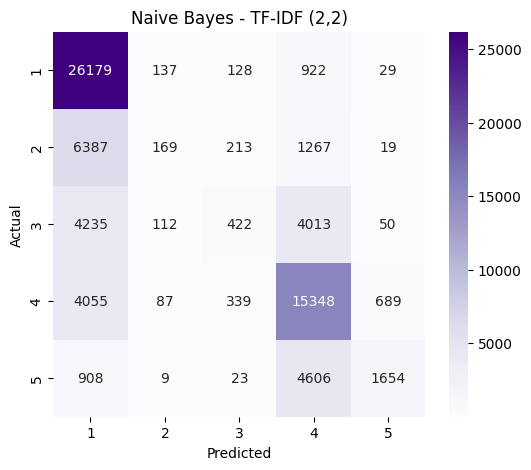

In [ ]:
grid_nb_bigram = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb_bigram.fit(X_train_bigram, y_train)

best_nb_bigram = grid_nb_bigram.best_estimator_

y_pred_bigram = best_nb_bigram.predict(X_test_bigram)

bigram_result = [
    "TF-IDF (2,2)",
    grid_nb_bigram.best_params_['alpha'],
    round(grid_nb_bigram.best_score_, 4),
    round(accuracy_score(y_test, y_pred_bigram), 4)
]

print("TF-IDF (2,2) Results:", bigram_result)

print("TF-IDF (2,2)\n", classification_report(y_test, y_pred_bigram))

cm = confusion_matrix(y_test, y_pred_bigram, labels=[1,2,3,4,5])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.title("Naive Bayes - TF-IDF (2,2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


BLOCK 4: TF-IDF (1,2)

TF-IDF (1,2) Results: ['TF-IDF (1,2)', 0.1, 0.6128, 0.6136]
TF-IDF (1,2)
               precision    recall  f1-score   support

           1       0.63      0.96      0.76     27395
           2       0.40      0.01      0.02      8055
           3       0.44      0.03      0.05      8832
           4       0.58      0.79      0.67     20518
           5       0.74      0.18      0.29      7200

    accuracy                           0.61     72000
   macro avg       0.56      0.39      0.36     72000
weighted avg       0.58      0.61      0.52     72000



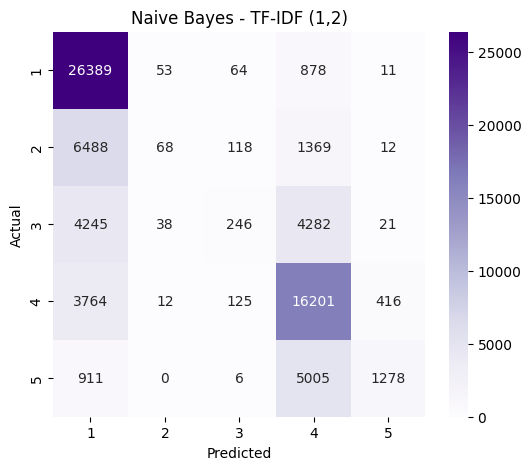

In [ ]:
grid_nb_12 = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb_12.fit(X_train_uni_bigram, y_train)

best_nb_12 = grid_nb_12.best_estimator_

y_pred_12 = best_nb_12.predict(X_test_uni_bigram)

tfidf12_result = [
    "TF-IDF (1,2)",
    grid_nb_12.best_params_['alpha'],
    round(grid_nb_12.best_score_, 4),
    round(accuracy_score(y_test, y_pred_12), 4)
]

print("TF-IDF (1,2) Results:", tfidf12_result)

print("TF-IDF (1,2)\n", classification_report(y_test, y_pred_12))

cm = confusion_matrix(y_test, y_pred_12, labels=[1,2,3,4,5])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.title("Naive Bayes - TF-IDF (1,2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FINAL COMPARISON TABLE

In [ ]:
results = [
    bow_result,
    uni_result,
    bigram_result,
    tfidf12_result
]

df = pd.DataFrame(results, columns=[
    "Feature", "Best Alpha", "CV Accuracy", "Test Accuracy"
])

print("\nFinal Comparison Table:\n")
print(df.sort_values(by="Test Accuracy", ascending=False))


Final Comparison Table:

        Feature  Best Alpha  CV Accuracy  Test Accuracy
0           BoW         1.0       0.6179         0.6220
3  TF-IDF (1,2)         0.1       0.6128         0.6136
1  TF-IDF (1,1)         0.1       0.6081         0.6135
2  TF-IDF (2,2)         0.1       0.6041         0.6079


**Explanation**

The Naive Bayes model was evaluated using different feature representations. The best performance was achieved using Bag of Words, with a test accuracy of 0.6220.
The results indicate that Naive Bayes performs better with simple frequency-based features such as BoW, as it relies on word occurrence probabilities.
Naive Bayes is a probabilistic model that assumes:
* Features are independent
* Data is based on word counts
BoW aligns well with these assumptions, which is why it outperforms TF-IDF and n-gram variations in this case.


=> Naive Bayes performs poorly with Word2Vec due to a fundamental mismatch:

MultinomialNB assumption:
* Works with count-based features (BoW, TF-IDF)
* Assumes discrete frequency values
Word2Vec characteristics:
* Produces dense vectors
* Uses continuous values
* Captures semantic relationships

This mismatch between model assumptions and feature representation leads to poor performance.

Naive Bayes is best suited for count-based representations like Bag of Words, while it is not appropriate for dense embeddings such as Word2Vec due to incompatible assumptions.

### **SVM + All Feature + Hyperparameter Tuning**

In [ ]:
from sklearn.svm import LinearSVC

param_grid_svm = {'C': [0.1, 1, 5]}

BLOCK 1: BoW (CountVectorizer)

In [ ]:
grid_svm_bow = GridSearchCV(
    LinearSVC(max_iter=2000, dual=False),
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm_bow.fit(X_train_count, y_train)

best_svm_bow = grid_svm_bow.best_estimator_

y_pred_svm_bow = best_svm_bow.predict(X_test_count)

svm_bow_result = [
    "BoW",
    grid_svm_bow.best_params_['C'],
    round(grid_svm_bow.best_score_, 4),
    round(accuracy_score(y_test, y_pred_svm_bow), 4)
]

print("SVM BoW Results:", svm_bow_result)

SVM BoW Results: ['BoW', 0.1, np.float64(0.6385), 0.6418]


 BLOCK 2: TF-IDF (Unigram)

In [ ]:
grid_svm_uni = GridSearchCV(
    LinearSVC(max_iter=2000),
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm_uni.fit(X_train_uni, y_train)

best_svm_uni = grid_svm_uni.best_estimator_

y_pred_svm_uni = best_svm_uni.predict(X_test_uni)

svm_uni_result = [
    "TF-IDF (1,1)",
    grid_svm_uni.best_params_['C'],
    round(grid_svm_uni.best_score_, 4),
    round(accuracy_score(y_test, y_pred_svm_uni), 4)
]

print("SVM TF-IDF (1,1) Results:", svm_uni_result)

SVM TF-IDF (1,1) Results: ['TF-IDF (1,1)', 0.1, np.float64(0.6473), 0.6512]


 BLOCK 3: TF-IDF (Bigram)

In [ ]:
grid_svm_bigram = GridSearchCV(
    LinearSVC(max_iter=2000, dual= True),
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm_bigram.fit(X_train_bigram, y_train)

best_svm_bigram = grid_svm_bigram.best_estimator_

y_pred_svm_bigram = best_svm_bigram.predict(X_test_bigram)

svm_bigram_result = [
    "TF-IDF (2,2)",
    grid_svm_bigram.best_params_['C'],
    round(grid_svm_bigram.best_score_, 4),
    round(accuracy_score(y_test, y_pred_svm_bigram), 4)
]

print("SVM TF-IDF (2,2) Results:", svm_bigram_result)

SVM TF-IDF (2,2) Results: ['TF-IDF (2,2)', 0.1, np.float64(0.6509), 0.6596]


BLOCK 4: TF-IDF (1,2)

In [ ]:
tfidf_uni_bigram = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=50000,
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_uni_bigram = tfidf_uni_bigram.fit_transform(train['processed_text'])
X_test_uni_bigram = tfidf_uni_bigram.transform(test['processed_text'])

print(X_train_uni_bigram.shape)
print(X_test_uni_bigram.shape)

(288000, 50000)
(72000, 50000)


In [ ]:
grid_svm_12 = GridSearchCV(
LinearSVC(class_weight='balanced', max_iter=3000)
    param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm_12.fit(X_train_uni_bigram, y_train)

best_svm_12 = grid_svm_12.best_estimator_

y_pred_svm_12 = best_svm_12.predict(X_test_uni_bigram)

svm_12_result = [
    "TF-IDF (1,2)",
    grid_svm_12.best_params_['C'],
    round(grid_svm_12.best_score_, 4),
    round(accuracy_score(y_test, y_pred_svm_12), 4)
]

print("SVM TF-IDF (1,2) Results:", svm_12_result)

SVM TF-IDF (1,2) Results: ['TF-IDF (1,2)', 1, np.float64(0.6458), 0.6482]


Final Comparison Table (SVM)

In [ ]:
svm_results = [
    svm_bow_result,
    svm_uni_result,
    svm_bigram_result,
    svm_12_result
]

df_svm = pd.DataFrame(svm_results, columns=[
    "Feature", "Best C", "CV Accuracy", "Test Accuracy"
])

print("\nSVM Comparison Table:\n")
print(df_svm.sort_values(by="Test Accuracy", ascending=False))


SVM Comparison Table:

        Feature  Best C  CV Accuracy  Test Accuracy
3  TF-IDF (1,2)       1       0.6458         0.6482
2  TF-IDF (2,2)       1       0.6458         0.6481
0           BoW       1       0.6377         0.6413
1  TF-IDF (1,1)       1       0.6355         0.6385



Classification Reports

In [ ]:
print("SVM BoW\n", classification_report(y_test, y_pred_svm_bow))
print("SVM TF-IDF (1,1)\n", classification_report(y_test, y_pred_svm_uni))
print("SVM TF-IDF (2,2)\n", classification_report(y_test, y_pred_svm_bigram))
print("SVM TF-IDF (1,2)\n", classification_report(y_test, y_pred_svm_12))

SVM BoW
               precision    recall  f1-score   support

           1       0.72      0.90      0.80     27395
           2       0.36      0.07      0.12      8055
           3       0.39      0.09      0.15      8832
           4       0.58      0.82      0.68     20518
           5       0.66      0.45      0.53      7200

    accuracy                           0.64     72000
   macro avg       0.54      0.47      0.46     72000
weighted avg       0.59      0.64      0.58     72000

SVM TF-IDF (1,1)
               precision    recall  f1-score   support

           1       0.72      0.90      0.80     27395
           2       0.32      0.08      0.13      8055
           3       0.37      0.15      0.21      8832
           4       0.60      0.77      0.67     20518
           5       0.61      0.48      0.54      7200

    accuracy                           0.64     72000
   macro avg       0.52      0.48      0.47     72000
weighted avg       0.59      0.64      0.59     72


Confusion Matrices


SVM Confusion Matrix: BoW


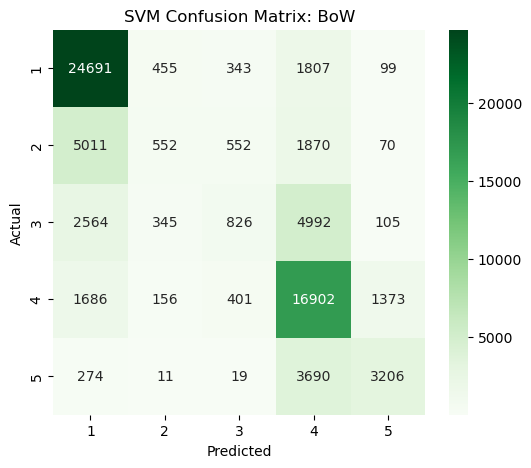


SVM Confusion Matrix: TF-IDF (1,1)


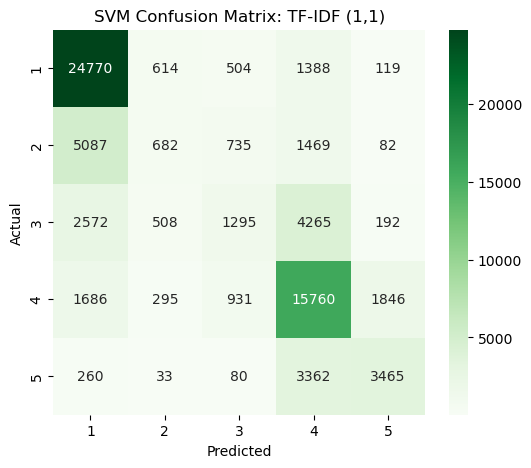


SVM Confusion Matrix: TF-IDF (2,2)


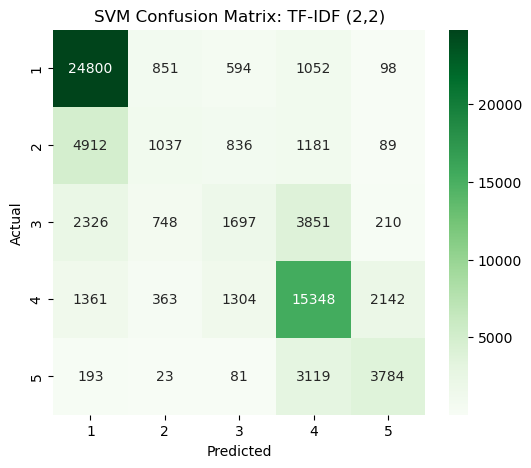


SVM Confusion Matrix: TF-IDF (1,2)


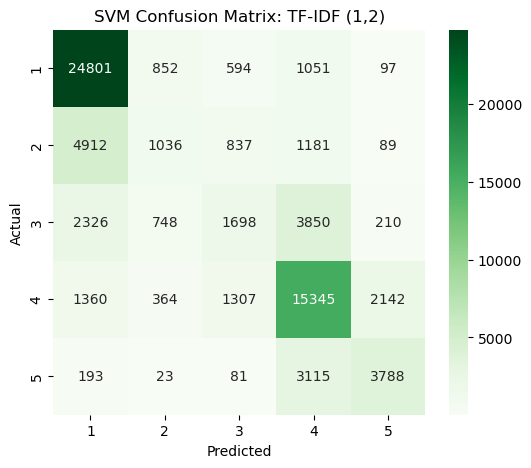

In [ ]:
predictions_svm = {
    "BoW": y_pred_svm_bow,
    "TF-IDF (1,1)": y_pred_svm_uni,
    "TF-IDF (2,2)": y_pred_svm_bigram,
    "TF-IDF (1,2)": y_pred_svm_12
}

for name, y_pred in predictions_svm.items():

    print("\n==============================")
    print(f"SVM Confusion Matrix: {name}")
    print("==============================")

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels,
                yticklabels=labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"SVM Confusion Matrix: {name}")
    plt.show()

**Explanation:**

The SVM model was evaluated using different feature representations. The best performance was achieved using TF-IDF (1,2) with a test accuracy of 0.6482, closely followed by TF-IDF (2,2). Bag of Words and TF-IDF (1,1) showed slightly lower performance.

The results indicate that using n-gram features improves performance by capturing contextual relationships between words, which helps in better classification.

SVM was chosen because it performs well on high-dimensional sparse data, such as TF-IDF features. It is effective in handling complex decision boundaries and provides consistent and reliable performance across different feature representations.

SVM with TF-IDF (1,2) was selected as the best configuration due to its strong performance and ability to effectively utilize contextual information from n-gram features.


### **Performance Comparison**

The models were evaluated using accuracy, classification reports, and confusion matrices.

| Model | Feature Representation | Best Parameter | CV Accuracy | Test Accuracy |
|------|----------------------|--------------|------------|--------------|
| Logistic Regression | TF-IDF (1,2) | C = 1 | ~0.66 | **0.6627** |
| SVM | TF-IDF (1,2) | C = 1 | ~0.65 | 0.6482 |
| Naive Bayes | BoW | alpha = 1 | ~0.62 | 0.6220 |


**Final Model Selection**

The best model selected was:

* Logistic Regression with TF-IDF (1,2)

Because:
- It achieved the highest test accuracy  
- It effectively captures both individual words and context  
- It is computationally efficient and stable  


**Error Analysis (Confusion Matrix Insights)**

Analysis of confusion matrices shows:

- Ratings **1 and 5** are predicted more accurately  
  → These contain strong sentiment words (e.g., "terrible", "excellent")

- Ratings **2, 3, and 4** are frequently misclassified  
  → These ratings have more subtle and overlapping language  

- **3-star reviews are the hardest to classify** because:
  - They often contain mixed sentiment  
  - They include both positive and negative expressions  
  - They lack strong polarity signals  

For example:
- A 3-star review may contain both "good service" and "long wait", making classification ambiguous.

# **Step 5 - Modelling text as a Sequence**

In this step, text is modeled as a sequence of tokens, where the order of words is preserved. Unlike Bag-of-Words approaches, this representation allows the model to capture contextual and semantic relationships between words.

Several sequence-based models can be used for this purpose, including:

* **Long Short-Term Memory (LSTM):** An improved version of RNN that can capture long-term dependencies using memory cells and gates.
* **Recurrent Neural Networks (RNNs):** Basic sequence models that process text step-by-step but suffer from vanishing gradient problems.
* **Gated Recurrent Unit (GRU):** A simplified variant of LSTM that is computationally efficient while still capturing important sequential patterns.
* **Bidirectional Encoder Representations from Transformers (BERT):** A transformer-based model that captures context from both directions and provides deep contextual understanding of text.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Encode Labels
le = LabelEncoder()
y_train_enc = le.fit_transform(train['rating'])
y_test_enc = le.transform(test['rating'])

In [ ]:
# Use Tokens from Previous Step
train_tokens = train['tokens'].values
test_tokens = test['tokens'].values

In [ ]:
# Build Vocabulary from Word2Vec
vocab = {word: i+1 for i, word in enumerate(w2v_model.wv.index_to_key)}

embedding_dim = w2v_model.vector_size
vocab_size = len(vocab)

In [ ]:
# Create Embedding Matrix
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))

for word, idx in vocab.items():
    embedding_matrix[idx] = w2v_model.wv[word]

In [ ]:
# Convert Tokens → Sequences
max_len = 50

def tokens_to_seq(tokens):
    seq = [vocab.get(word, 0) for word in tokens]
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

X_train_seq = np.array([tokens_to_seq(s) for s in train_tokens])
X_test_seq = np.array([tokens_to_seq(s) for s in test_tokens])

# Convert to Tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

In [ ]:
# Dataset Class
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
# Train / Validation Split
full_dataset = TextDataset(X_train_tensor, y_train_tensor)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

test_dataset = TextDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Train batches: 7200
Validation batches: 1800
Test batches: 2250


### **A: Modelling Text as a Sequence using LSTM**

In this step, text is modeled as a sequence rather than a bag-of-words representation.

Long Short-Term Memory (LSTM) networks are used to capture word order and long-term dependencies in the text. Unlike basic RNNs, LSTMs address the vanishing gradient problem and are better at learning contextual relationships over longer sequences.

**Embedding Representation**

Pre-trained Word2Vec embeddings are used to convert words into dense vector representations.

The embedding layer is initialized using these pre-trained vectors and is kept non-trainable, allowing the model to retain semantic knowledge while reducing overfitting and computational cost.

**LSTM Model Architecture**

The model consists of:

* An embedding layer initialized with Word2Vec vectors
* A 2-layer LSTM network to process sequential text data
* Dropout layers to reduce overfitting
* A fully connected layer for classification

The final hidden state of the LSTM is used to represent the entire sequence and is passed to the output layer for prediction.

In [ ]:
# LSTM Classifier

class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim):
        super().__init__()

        num_embeddings, embed_dim = embedding_matrix.shape

        # Embedding
        self.embedding = nn.Embedding(num_embeddings, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = False

        # LSTM with dropout
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.4
        )

        # Additional dropout layer
        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)

        h = h_n[-1]
        h = self.dropout(h)
        return self.fc(h)

# Model Initialization

hidden_dim = 64
output_dim = len(np.unique(y_train_enc))

model = LSTMClassifier(embedding_matrix, hidden_dim, output_dim).to(device)

criterion = nn.CrossEntropyLoss()

# Adam with weight decay for L2 regularization
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

**For training:**
- The loss function used is CrossEntropyLoss for multi-class classification.
- The optimizer is Adam with a learning rate of 0.001 and weight decay for L2 regularization.

**Training Procedure**

The model is trained for 10 epochs using mini-batch gradient descent.

During each epoch, the model is set to training mode and processes the data in batches. For each batch:
- Input data and labels are moved to the selected device
- The optimizer gradients are reset
- A forward pass is performed to obtain predictions
- The loss is computed using CrossEntropyLoss
- Backpropagation is applied to compute gradients
- Model parameters are updated using the optimizer


Epoch 1
Train Acc: 0.5980 | Val Acc: 0.6410

Epoch 2
Train Acc: 0.6412 | Val Acc: 0.6551

Epoch 3
Train Acc: 0.6525 | Val Acc: 0.6592

Epoch 4
Train Acc: 0.6586 | Val Acc: 0.6539

Epoch 5
Train Acc: 0.6625 | Val Acc: 0.6618

Epoch 6
Train Acc: 0.6659 | Val Acc: 0.6585

Epoch 7
Train Acc: 0.6688 | Val Acc: 0.6623

Epoch 8
Train Acc: 0.6709 | Val Acc: 0.6634

Epoch 9
Train Acc: 0.6733 | Val Acc: 0.6607

Epoch 10
Train Acc: 0.6765 | Val Acc: 0.6606


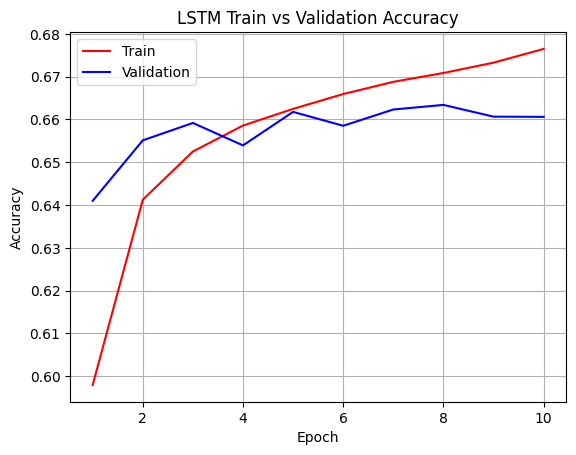


Final Test Accuracy: 0.662

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.90      0.82     27395
           1       0.39      0.15      0.21      8055
           2       0.39      0.19      0.26      8832
           3       0.63      0.77      0.69     20518
           4       0.63      0.59      0.61      7200

    accuracy                           0.66     72000
   macro avg       0.56      0.52      0.52     72000
weighted avg       0.62      0.66      0.63     72000



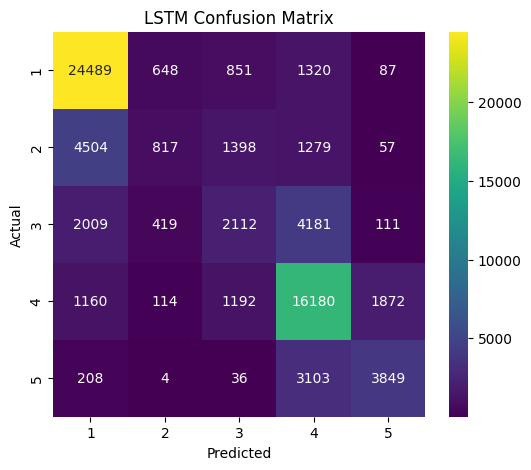

In [ ]:
epochs = 10

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    # -------- PRINT --------
    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # -------- STORE --------
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

# Plot Accuracy Curves
epochs_ran = len(train_acc_list)

plt.figure()
plt.plot(range(1, epochs_ran+1), train_acc_list, label="Train", color='red')
plt.plot(range(1, epochs_ran+1), val_acc_list, label="Validation", color='blue')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Train vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

# Test Evaluation
model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())

print("\nFinal Test Accuracy:", round(accuracy_score(y_test_enc, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred))

# Confusion Matrix
# Use original encoded labels (0–4)
cm = confusion_matrix(y_test_enc, y_pred, labels=[0,1,2,3,4])

# Plot with rating labels (1–5)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=[1,2,3,4,5],   # Predicted labels
    yticklabels=[1,2,3,4,5]    # Actual labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

**Results Explanation**

The LSTM model shows a gradual improvement in both training and validation accuracy during the first few epochs. The validation accuracy increases until around **Epoch 8**, after which it slightly fluctuates. This indicates that the model is learning useful patterns and does not suffer from severe overfitting.

The final test accuracy is **66.2%**, which is close to the validation accuracy. This shows that the model generalizes well to unseen data.

The **confusion matrix** shows how well the model predicts each rating (where 0–4 correspond to ratings 1–5). This indicates that the model performs better on extreme or common ratings (1 and 4), but struggles to correctly distinguish between middle ratings (2 and 3).


### **B: Modelling Text as a Sequence using RNN**

In this step, text is modeled as a sequence rather than a bag-of-words representation.

Recurrent Neural Networks (RNNs) are used to capture word order and contextual dependencies in the text. This allows the model to learn patterns based on sequence information, which is not possible with TF-IDF or BoW approaches.

### Embedding Representation

Pre-trained Word2Vec embeddings are used to convert words into dense vectors.

The embedding layer is initialized with these vectors and is set to be trainable so that it can adapt to the classification task during training.

### RNN Model Architecture

The model consists of:
- An embedding layer initialized with Word2Vec vectors
- A 2-layer RNN to process sequences
- Dropout to reduce overfitting
- A fully connected layer for classification

The final hidden state of the RNN is used to predict the output class.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_enc)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
# RNN Classifier
class RNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim):
        super().__init__()

        num_embeddings, embed_dim = embedding_matrix.shape

        # Embedding
        self.embedding = nn.Embedding(num_embeddings, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = True

        # Simple RNN
        self.rnn = nn.RNN(
            embed_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.rnn(x)

        h = h_n[-1]
        h = self.dropout(h)

        return self.fc(h)


# Initialize
model = RNNClassifier(embedding_matrix, hidden_dim, output_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

### Model Initialization

The RNN model is initialized with the embedding matrix, hidden dimension, and number of output classes.
The Adam optimizer is used to update model parameters during training.

### Training Procedure

The model is trained for 10 epochs using mini-batches.

For each epoch:
- Forward pass is performed
- Loss is calculated using CrossEntropyLoss
- Backpropagation is applied
- Model parameters are updated using Adam optimizer

Training and validation accuracy are tracked at each epoch.


Epoch 1
Train Acc: 0.4190 | Val Acc: 0.3411

Epoch 2
Train Acc: 0.4111 | Val Acc: 0.3580

Epoch 3
Train Acc: 0.4280 | Val Acc: 0.5500

Epoch 4
Train Acc: 0.4229 | Val Acc: 0.4400

Epoch 5
Train Acc: 0.4393 | Val Acc: 0.4337

Epoch 6
Train Acc: 0.4251 | Val Acc: 0.3760

Epoch 7
Train Acc: 0.4074 | Val Acc: 0.4534

Epoch 8
Train Acc: 0.4321 | Val Acc: 0.4531

Epoch 9
Train Acc: 0.4487 | Val Acc: 0.4532

Epoch 10
Train Acc: 0.4549 | Val Acc: 0.4878


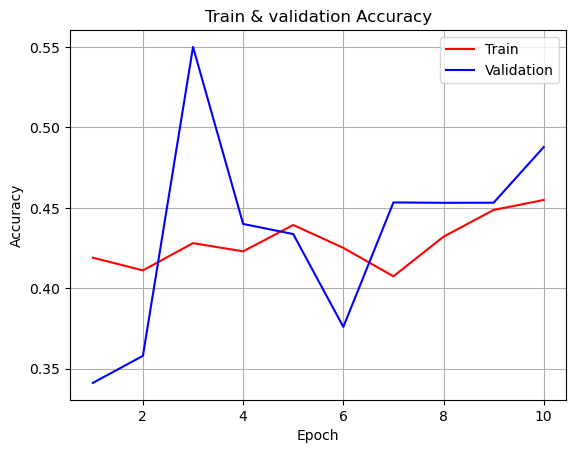


Final Test Accuracy: 0.4878

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.80      0.72     27395
           1       0.26      0.01      0.02      8055
           2       0.21      0.36      0.26      8832
           3       0.56      0.25      0.35     20518
           4       0.35      0.65      0.45      7200

    accuracy                           0.49     72000
   macro avg       0.41      0.42      0.36     72000
weighted avg       0.50      0.49      0.45     72000



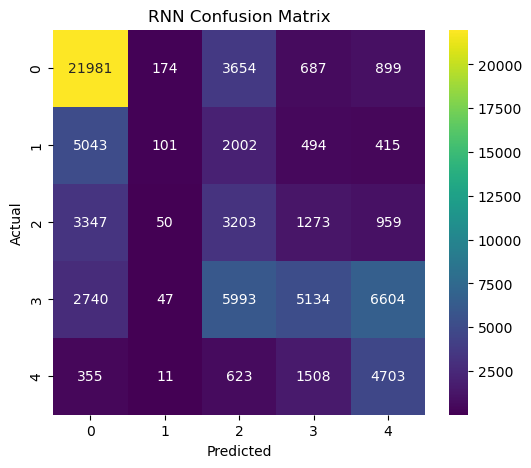

In [ ]:
epochs = 10

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

# Initialize before loop
best_val_acc = 0
counter = 0
patience = 2

for epoch in range(epochs):
    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    # -------- PRINT --------
    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # -------- STORE --------
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)


# Accuracy Plot

epochs_ran = len(train_acc_list)

plt.figure()
plt.plot(range(1, epochs+1), train_acc_list,  label="Train", color='red')
plt.plot(range(1, epochs+1), val_acc_list, label="Validation", color='blue')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train & validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Test Evaluation
model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())

print("\nFinal Test Accuracy:", round(accuracy_score(y_test_enc, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred))

# Confusion Matrix
labels = list(range(len(le.classes_)))
cm = confusion_matrix(y_test_enc, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")
plt.show()

### Conclusion (RNN Model Performance)

The RNN model achieved a final test accuracy of approximately **48.8%**, which is lower than the previous result but provides a more balanced and realistic evaluation of model performance.

After applying class weighting, the model is now able to predict **all classes (0–4)** instead of being biased toward only a few dominant classes. This is clearly reflected in the confusion matrix, where predictions are distributed across all categories.

From the classification report and confusion matrix, it is observed that:
- The model performs well for **class 0**, achieving high precision and recall.
- Performance for **class 4** has significantly improved, with better recall compared to the previous model.
- The model is now able to predict **classes 1 and 2**, although performance for these classes remains low.
- There is still confusion between neighboring classes (e.g., 2, 3, and 4), indicating difficulty in distinguishing similar ratings.

The decrease in overall accuracy is due to the model no longer favoring majority classes. Instead, it provides a more balanced classification across all categories, which is more appropriate for real-world applications.

Compared to bag-of-words and TF-IDF models:
- The RNN captures **sequential and contextual information** effectively.
- It provides a more meaningful representation of text using embeddings.
- However, it still struggles with fine-grained distinctions between similar sentiment levels.

Overall, the RNN model demonstrates improved class balance and better generalization across all categories after applying class weights. While the accuracy is slightly lower, the model is now more robust and fair. Further improvements can be achieved using advanced architectures such as LSTM or GRU, which are better at capturing long-term dependencies in text.

### **C: Modelling Text as a Sequence using GRU**

In this step, text is modeled as a sequence rather than a bag-of-words representation.

Gated Recurrent Unit (GRU) networks are used to capture word order and contextual dependencies in the text. GRU is a simplified version of LSTM that uses gating mechanisms to control the flow of information, making it more efficient while still handling sequential patterns effectively.

**Embedding Representation**

Pre-trained Word2Vec embeddings are used to convert words into dense vector representations.

The embedding layer is initialized using these vectors and is set to be trainable, allowing the model to fine-tune word representations based on the classification task and improve performance.

**GRU Model Architecture**

The model consists of:

* An embedding layer initialized with Word2Vec vectors
* A 2-layer GRU network to process sequential text data
* Dropout layers (0.3) to reduce overfitting
* A fully connected layer for classification

The final hidden state of the GRU is used to represent the sequence and is passed to the output layer for prediction.

In [ ]:
# GRU Classifier
class GRUClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim):
        super().__init__()

        num_embeddings, embed_dim = embedding_matrix.shape

        # Embedding
        self.embedding = nn.Embedding(num_embeddings, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = True

        # GRU with dropout
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        # Additional dropout
        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.gru(x)

        h = h_n[-1]
        h = self.dropout(h)

        return self.fc(h)

# Model Initialization
hidden_dim = 64
output_dim = len(np.unique(y_train_enc))

model = GRUClassifier(embedding_matrix, hidden_dim, output_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

**For training:**
- The loss function used is CrossEntropyLoss for multi-class classification.
- The optimizer is Adam with a learning rate of 0.001 and weight decay for regularization.

The model is trained for 10 epochs using mini-batch gradient descent.

During each epoch, the model is set to training mode and processes data in batches. For each batch:
- Input data and labels are moved to the selected device
- Gradients are reset using the optimizer
- A forward pass is performed to obtain predictions
- The loss is computed using CrossEntropyLoss
- Backpropagation is applied to compute gradients
- Model parameters are updated using the optimizer



Epoch 1
Train Acc: 0.6367 | Val Acc: 0.6575

Epoch 2
Train Acc: 0.6612 | Val Acc: 0.6593

Epoch 3
Train Acc: 0.6699 | Val Acc: 0.6593

Epoch 4
Train Acc: 0.6791 | Val Acc: 0.6611

Epoch 5
Train Acc: 0.6908 | Val Acc: 0.6570

Epoch 6
Train Acc: 0.7040 | Val Acc: 0.6544

Epoch 7
Train Acc: 0.7208 | Val Acc: 0.6535

Epoch 8
Train Acc: 0.7402 | Val Acc: 0.6391

Epoch 9
Train Acc: 0.7593 | Val Acc: 0.6238

Epoch 10
Train Acc: 0.7756 | Val Acc: 0.6197


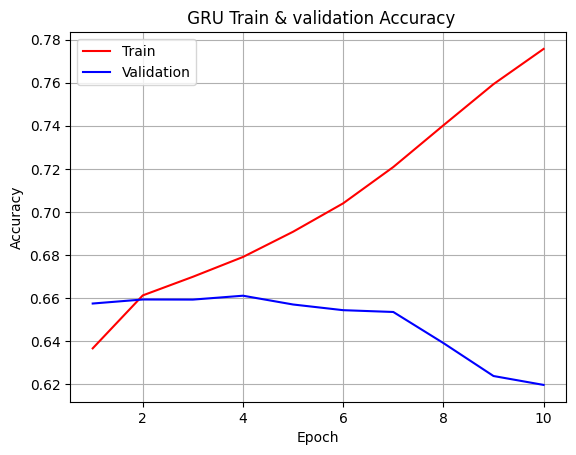


Final Test Accuracy: 0.6221

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.81      0.79     27395
           1       0.31      0.22      0.26      8055
           2       0.32      0.34      0.33      8832
           3       0.63      0.70      0.66     20518
           4       0.61      0.51      0.55      7200

    accuracy                           0.62     72000
   macro avg       0.53      0.51      0.52     72000
weighted avg       0.61      0.62      0.61     72000



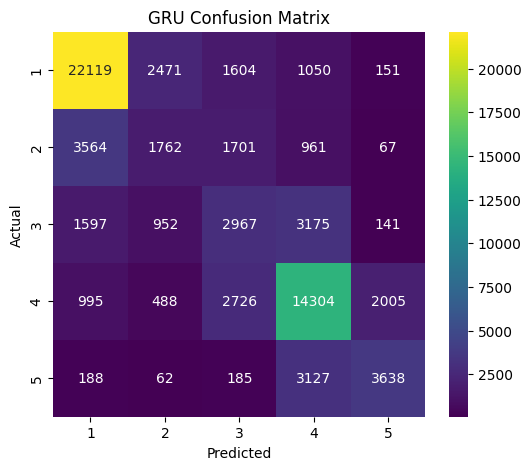

In [ ]:
epochs = 10

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    # -------- PRINT --------
    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # -------- STORE --------
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

epochs_ran = len(train_acc_list)

# Accuracy Plot
plt.figure()
plt.plot(range(1, epochs+1), train_acc_list,  label="Train", color='red')
plt.plot(range(1, epochs+1), val_acc_list, label="Validation", color='blue')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(" GRU Train & validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Test Evaluation
model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_pred.extend(preds.cpu().numpy())

print("\nFinal Test Accuracy:", round(accuracy_score(y_test_enc, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred))

# Confusion Matrix
# Use original encoded labels (0–4)
cm = confusion_matrix(y_test_enc, y_pred, labels=[0,1,2,3,4])

# Plot with rating labels (1–5)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=[1,2,3,4,5],   # Predicted labels
    yticklabels=[1,2,3,4,5]    # Actual labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

**Results Explanation**

The GRU model shows an increase in training accuracy from **63.67% to 77.56%**, but validation accuracy peaks early around **66.11%** and then gradually declines. This indicates that the model starts to overfit after a few epochs.

The final test accuracy is **62.21%**, which is lower than LSTM and BERT, suggesting limited generalization performance.

**Confusion Matrix Explanation**

- **Ratings 1 and 4** are predicted relatively well.  
- **Ratings 2 and 3** show significant misclassification:
  - Rating 2 is often predicted as Rating 1 or 3  
  - Rating 3 is frequently confused with Rating 4  
- **Rating 5** is sometimes misclassified as Rating 4  

This shows difficulty in distinguishing similar middle ratings.

**Classification Report Explanation**

- Strong performance for **Rating 1 and Rating 4**  
- Lower precision and recall for **Ratings 2 and 3**  
- **Macro F1-score (0.52)** indicates class imbalance and uneven performance across classes  

**Overall Interpretation**

The GRU model captures sequential information better than basic RNN but suffers from overfitting and lower performance compared to LSTM and BERT. While it improves over RNN, it is less effective than more advanced models in handling complex contextual relationships.

### **D: Modelling Text as a Sequence using BERT**

Bidirectional Encoder Representations from Transformers (BERT) is used to capture contextual relationships in text. Unlike RNN-based models, BERT processes the entire sequence simultaneously and considers both left and right context, allowing it to understand deeper semantic meaning in the text.

**Embedding Representation**

Instead of using pre-trained Word2Vec embeddings, BERT uses its own contextual embeddings generated through a transformer architecture.

Each word is represented based on its context within the sentence, meaning the same word can have different representations depending on its surrounding words. This provides a more powerful and dynamic representation compared to static embeddings.

**BERT Model Architecture**

The model consists of:


* A pre-trained BERT encoder (bert-base-uncased)
* A tokenizer to convert text into input IDs and attention masks
* Transformer layers that capture bidirectional context
* A classification head (fully connected layer) for predicting output classes

Only the last few layers of BERT are fine-tuned during training, while earlier layers remain frozen to reduce computational cost and overfitting.

In [ ]:
!pip install transformers

Using device: cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_1631/2855104590.py:110


Epoch 1
Train Acc: 0.6331 | Val Acc: 0.6635


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 2
Train Acc: 0.6629 | Val Acc: 0.6746


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 3
Train Acc: 0.6685 | Val Acc: 0.6760


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 4
Train Acc: 0.6734 | Val Acc: 0.6790


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 5
Train Acc: 0.6755 | Val Acc: 0.6808


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 6
Train Acc: 0.6777 | Val Acc: 0.6810


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 7
Train Acc: 0.6780 | Val Acc: 0.6832


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 8
Train Acc: 0.6804 | Val Acc: 0.6821


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 9
Train Acc: 0.6814 | Val Acc: 0.6841


/tmp/ipykernel_1631/2855104590.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 10
Train Acc: 0.6821 | Val Acc: 0.6838


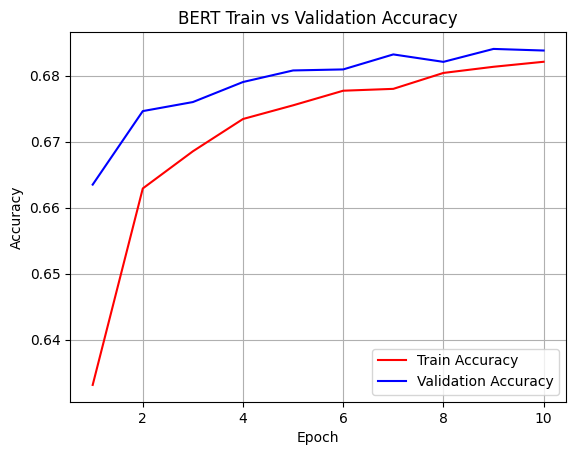


Test Accuracy: 0.6844

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.91      0.84     27395
           1       0.41      0.19      0.26      8055
           2       0.42      0.27      0.33      8832
           3       0.68      0.78      0.73     20518
           4       0.66      0.60      0.63      7200

    accuracy                           0.68     72000
   macro avg       0.59      0.55      0.56     72000
weighted avg       0.65      0.68      0.66     72000



NameError: name 'cm' is not defined

<Figure size 600x500 with 0 Axes>

In [ ]:
# IMPORTS
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# TOKENIZER
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# DATASET
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# CLASS WEIGHTS
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 6. DATA LOADERS
full_dataset = BERTDataset(train['clean_text'], y_train_enc, tokenizer)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

test_dataset = BERTDataset(test['clean_text'], y_test_enc, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32)

# MODEL
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(np.unique(y_train_enc))
)

model.to(device)

#
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# OPTIMIZER + SCHEDULER
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5
)

epochs = 10

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# LOSS FUNCTION
loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)

# Mixed precision (VERY IMPORTANT)
scaler = torch.cuda.amp.GradScaler()

# TRAINING
train_acc_list = []
val_acc_list = []

for epoch in range(epochs):

    model.train()
    train_preds, train_labels = [], []

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds = torch.argmax(outputs.logits, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    # VALIDATION
    model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

# Plot Accuracy
epochs_ran = len(train_acc_list)

plt.figure()
plt.plot(range(1, epochs_ran+1), train_acc_list, label="Train Accuracy", color='red')
plt.plot(range(1, epochs_ran+1), val_acc_list, label="Validation Accuracy", color='blue')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT Train vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

# TEST
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("\nTest Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

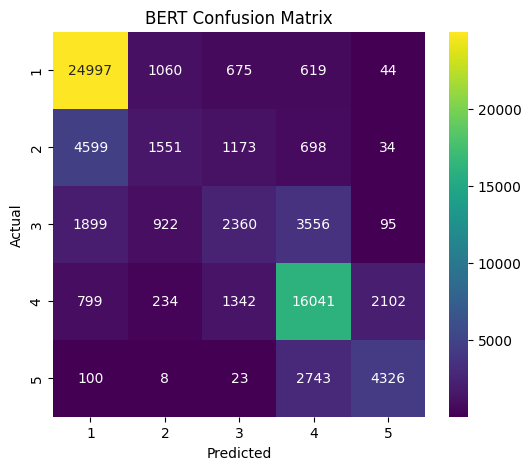

In [ ]:
# Confusion Matrix
# Use original encoded labels (0–4)
cm = confusion_matrix(y_test_enc, y_pred, labels=[0,1,2,3,4])

# Plot with rating labels (1–5)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=[1,2,3,4,5],   # Predicted labels
    yticklabels=[1,2,3,4,5]    # Actual labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")
plt.show()

**Results Explanation**

The BERT model shows steady improvement, with validation accuracy increasing from **66.35%** to **68.41%**.

The model continues to improve gradually without significant overfitting, as the gap between training and validation accuracy remains small throughout training. This suggests that the model generalizes well to unseen data.

The final test accuracy achieved is **68.44%**, which is higher than both the LSTM and RNN models, demonstrating the effectiveness of BERT in capturing contextual information.

**Confusion Matrix Explanation**

The confusion matrix shows the performance of the model across different rating classes (1–5):

- **Ratings 1 and 4** are predicted accurately.  
- **Ratings 2 and 3** are often misclassified (2 → 1, 3 → 4).  
- **Rating 5** shows moderate performance but is sometimes confused with 4.  

This indicates that the model performs better on extreme or more distinct ratings, while it struggles to differentiate between similar middle ratings.

**Classification Report Explanation**

- Strong performance for **Ratings 1 and 4**  
- Lower recall for **Ratings 2 and 3**  
- Lower **macro F1 (0.56)** indicates class imbalance  

**Overall Interpretation**

The BERT model provides the best performance among all models tested, achieving the highest accuracy and better overall classification results. Its ability to capture bidirectional context makes it highly effective for text classification tasks. Further improvements could be achieved by addressing class imbalance and fine-tuning additional layers.

### **=============== Performance Comparison (BoW vs Sequence Models) ====================**

To evaluate the effectiveness of sequence models, their performance is compared with the **Bag-of-Words (BoW)** baseline from previous steps.

| Model | Representation | Test Accuracy (%) |
|------|--------------|------------------|
| Naïve Bayes | BoW | 62.20 |
| Logistic Regression | BoW | 64.87 |
| SVM | BoW | 64.13 |
| RNN | Word2Vec (Sequence) | 48.78 |
| GRU | Word2Vec (Sequence) | 62.21 |
| LSTM | Word2Vec (Sequence) | 66.20 |
| BERT | Contextual (Sequence) | **68.44** |

**Key Observations**

- **BERT achieves the highest accuracy (68.44%)**, outperforming all BoW-based models.
- **LSTM (66.20%)** performs better than all BoW models, showing the advantage of sequence learning.
- **GRU (62.21%)** performs similarly to Naïve Bayes but slightly below stronger BoW models like Logistic Regression.
- **RNN performs poorly (48.78%)**, highlighting its limitation in capturing long-term dependencies.
- BoW models perform reasonably well but fail to capture **word order and contextual meaning**.

**Conclusion**

Sequence models improve performance by incorporating word order and contextual information. Among them, **BERT provides the best results**, demonstrating the superiority of transformer-based models over traditional Bag-of-Words approaches.

# **Step 6 - Topic Modelling of high and low ratings**

In this step, topic modelling was performed to analyze themes in high-rated and low-rated reviews separately. Based on the processed text from previous steps, vectorization using unigram and bigram features was applied to convert text into numerical form.

The dataset was divided into:

* High-rated reviews (≥4)
* Low-rated reviews (≤2)

Latent Dirichlet Allocation (LDA) was used to extract 10–20 topics from each group. Each review was assigned to its dominant topic, and topic distributions were compared between high and low ratings.

This analysis helps identify key themes associated with customer satisfaction and dissatisfaction.

**Text Vectorization**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_high = CountVectorizer(
    stop_words='english',
    min_df=10,
    max_features=5000,
    ngram_range=(1,2)
)

vectorizer_low = CountVectorizer(
    stop_words='english',
    max_df=0.85,
    min_df=10,
    max_features=5000,
    ngram_range=(1,2)
)

**Explanation**

* Text data is converted into numerical form using CountVectorizer.
* Unigrams and bigrams are used to capture both individual words and phrases.

**Split High and Low Reviews**

In [ ]:
high_reviews = train[train['rating'] >= 4]['processed_text'].dropna()
low_reviews = train[train['rating'] <= 2]['processed_text'].dropna()

print("High reviews:", len(high_reviews))
print("Low reviews:", len(low_reviews))

High reviews: 110873
Low reviews: 141801


**Explanation**

The dataset is divided into:

* High-rated reviews (≥4) → positive sentiment
* Low-rated reviews (≤2) → negative sentiment

This allows separate analysis of positive and negative topics.

**Transform Text into Matrix**

In [ ]:
high_X = vectorizer_high.fit_transform(high_reviews)
low_X = vectorizer_low.fit_transform(low_reviews)

**Explanation**

The text is transformed into a document-term matrix, where:

* Rows represent reviews
* Columns represent words/features

This matrix is used as input for topic modelling.

**Apply LDA Topic Modelling**

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda_high = LatentDirichletAllocation(
    n_components=20,
    max_iter=5,
    learning_method='online',
    n_jobs=-1,
    random_state=42
)

lda_low = LatentDirichletAllocation(
    n_components=20,
    max_iter=5,
    learning_method='online',
    n_jobs=-1,
    random_state=42
)

lda_high.fit(high_X)
lda_low.fit(low_X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",20
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",5
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


**Explanation**

LDA (Latent Dirichlet Allocation) is used to extract hidden topics from text.

* n_components=20 → number of topics
* Each topic is a group of related words
* Separate models are trained for high and low reviews

**Generate Topic Labels**

In [ ]:
def generate_label(words):
    # Separate bigrams and unigrams
    bigrams = [w for w in words if len(w.split()) == 2]
    unigrams = [w for w in words if len(w.split()) == 1]

    # Step 1: Prefer meaningful bigrams
    if len(bigrams) >= 2:
        label_words = bigrams[:2]

    elif len(bigrams) == 1:
        # combine 1 bigram + 1 unigram → 3 words
        if len(unigrams) >= 1:
            label_words = [bigrams[0], unigrams[0]]
        else:
            label_words = [bigrams[0]]

    else:
        # fallback → top 2-3 unigrams
        label_words = unigrams[:3]

    # Flatten into words
    final_words = []
    seen = set()

    for phrase in label_words:
        for w in phrase.split():
            if w not in seen:
                final_words.append(w)
                seen.add(w)

    return " ".join(final_words[:3]).title()

**Explanation**

Topic labels are generated automatically using top words:

* Priority is given to bigrams (phrases)
* Ensures labels are meaningful and interpretable
* No manual labeling is used

**Display Topics**

In [ ]:
display_topics_with_labels(
    lda_high,
    vectorizer_high.get_feature_names_out(),
    title="HIGH RATING TOPICS"
)


HIGH RATING TOPICS
Topic 1: nice, price, place, shop, reasonable, item, fair, decent, nice place, employee
→ Label: Nice Place

Topic 2: store, original, google, translated, translated google, la, good, muy, hot, el
→ Label: Translated Google Store

Topic 3: care, great, wonderful, staff, know, beautiful, efficient, facility, neighborhood, took
→ Label: Care Great Wonderful

Topic 4: car, need, company, help, fast, professional, overall, recommend, job, service
→ Label: Car Need Company

Topic 5: best, ive, nail, town, hand, living, salon, kind, special, ok
→ Label: Best Ive Nail

Topic 6: time, good, wait, patient, long, phone, pretty, dont, doctor, appointment
→ Label: Time Good Wait

Topic 7: good, friendly, staff, food, great, price, people, great job, staff friendly, friendly staff
→ Label: Great Job Staff

Topic 8: didnt, guy, good, kid, really, going, like, thing, loved, stuff
→ Label: Didnt Guy Good

Topic 9: work, thank, time, week, look, process, really, working, looking, pr

In [ ]:
display_topics_with_labels(
    lda_low,
    vectorizer_low.get_feature_names_out(),
    title="LOW RATING TOPICS"
)


LOW RATING TOPICS
Topic 1: car, shop, dog, took, repair, light, owner, receipt, happen, oil
→ Label: Car Shop Dog

Topic 2: place, bad, people, review, star, worst, experience, business, dont, child
→ Label: Place Bad People

Topic 3: like, didnt, im, different, asked, hair, people, said, really, thing
→ Label: Like Didnt Im

Topic 4: year, problem, issue, home, day, work, need, come, care, new
→ Label: Year Problem Issue

Topic 5: store, order, return, item, delivery, purchase, policy, ordered, ready, wish
→ Label: Store Order Return

Topic 6: price, nail, left, quality, place, expensive, picture, friendly, great, job
→ Label: Price Nail Left

Topic 7: money, company, phone, answer, dont, door, pay, fee, charge, answer phone
→ Label: Answer Phone Money

Topic 8: food, google, la, que, original, box, translated, translated google, post, el
→ Label: Translated Google Food

Topic 9: company, month, later, email, work, day, paid, time, week, received
→ Label: Company Month Later

Topic 1

**Explanation**

Top words for each topic are displayed along with auto-generated labels.

This helps interpret what each topic represents.

**Dominant Topic Assignment**

In [ ]:
# DOMINANT TOPIC
import numpy as np

high_topics_dist = lda_high.transform(high_X)
low_topics_dist = lda_low.transform(low_X)

high_dominant = np.argmax(high_topics_dist, axis=1)
low_dominant = np.argmax(low_topics_dist, axis=1)

print("High rating dominant topics distribution:")
print(np.bincount(high_dominant))
print("\nLow rating dominant topics distribution:")
print(np.bincount(low_dominant))

High rating dominant topics distribution:
[ 5441  3909  2516  9982  2743  4465 10683  2659  7072  4303  6118  9000
  7574  8062  3471  6002  5962  2832  3299  4780]

Low rating dominant topics distribution:
[ 3577  7996 15623 11431  1603  7881  5098  5095 14063  1504  6657  7405
  4464  9805  2571  3219 14566  7635  8516  3092]


**Explanation**

Each review is assigned to its dominant topic:

* The topic with highest probability is selected
* This helps categorize reviews into topics

**Topic Frequency Comparison**

In [ ]:
# FREQUENCY COMPARISON
import pandas as pd

high_counts = pd.Series(high_dominant).value_counts()
low_counts = pd.Series(low_dominant).value_counts()

all_topics = range(lda_high.n_components)

high_counts = high_counts.reindex(all_topics, fill_value=0)
low_counts = low_counts.reindex(all_topics, fill_value=0)

comparison_df = pd.DataFrame({
    'Topic': all_topics,
    'High_Count': high_counts.values,
    'Low_Count': low_counts.values
})

comparison_df['Difference'] = comparison_df['High_Count'] - comparison_df['Low_Count']

comparison_df['High_%'] = comparison_df['High_Count'] / comparison_df['High_Count'].sum()
comparison_df['Low_%'] = comparison_df['Low_Count'] / comparison_df['Low_Count'].sum()

print("\n=== Topic Comparison Table ===")
print(comparison_df)



=== Topic Comparison Table ===
    Topic  High_Count  Low_Count  Difference    High_%     Low_%
0       0        5441       3577        1864  0.049074  0.025225
1       1        3909       7996       -4087  0.035257  0.056389
2       2        2516      15623      -13107  0.022693  0.110176
3       3        9982      11431       -1449  0.090031  0.080613
4       4        2743       1603        1140  0.024740  0.011305
5       5        4465       7881       -3416  0.040271  0.055578
6       6       10683       5098        5585  0.096353  0.035952
7       7        2659       5095       -2436  0.023982  0.035931
8       8        7072      14063       -6991  0.063785  0.099174
9       9        4303       1504        2799  0.038810  0.010606
10     10        6118       6657        -539  0.055180  0.046946
11     11        9000       7405        1595  0.081174  0.052221
12     12        7574       4464        3110  0.068312  0.031481
13     13        8062       9805       -1743  0.072714  0.

**Explanation**

Topic frequencies are compared between:

* High-rated reviews
* Low-rated reviews

This highlights which topics are more common in each group.

In [ ]:
# Display top topics in HIGH and LOW reviews based on difference

print("\n=== Top Topics in HIGH Reviews ===")
print(comparison_df.sort_values(by='Difference', ascending=False).head(5))

print("\n=== Top Topics in LOW Reviews ===")
print(comparison_df.sort_values(by='Difference').head(5))


=== Top Topics in HIGH Reviews ===
    Topic  High_Count  Low_Count  Difference    High_%     Low_%
6       6       10683       5098        5585  0.096353  0.035952
12     12        7574       4464        3110  0.068312  0.031481
9       9        4303       1504        2799  0.038810  0.010606
15     15        6002       3219        2783  0.054134  0.022701
0       0        5441       3577        1864  0.049074  0.025225

=== Top Topics in LOW Reviews ===
    Topic  High_Count  Low_Count  Difference    High_%     Low_%
2       2        2516      15623      -13107  0.022693  0.110176
16     16        5962      14566       -8604  0.053773  0.102721
8       8        7072      14063       -6991  0.063785  0.099174
18     18        3299       8516       -5217  0.029755  0.060056
17     17        2832       7635       -4803  0.025543  0.053843


**Visualization**

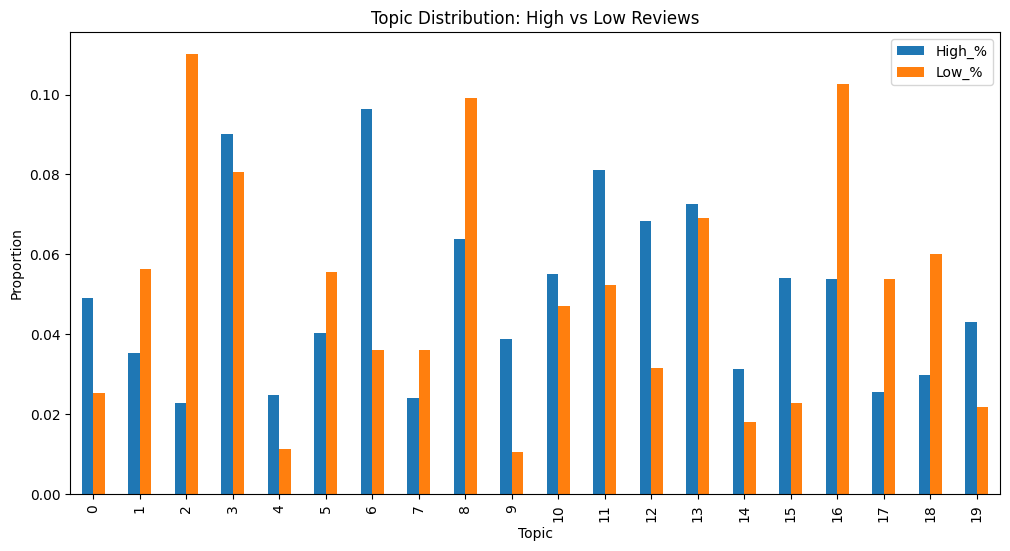

In [ ]:
# Visualize topic distribution
import matplotlib.pyplot as plt

comparison_df.set_index('Topic')[['High_%', 'Low_%']].plot(kind='bar', figsize=(12,6))
plt.title("Topic Distribution: High vs Low Reviews")
plt.ylabel("Proportion")
plt.xlabel("Topic")
plt.show()

**Explanation**

A bar chart is used to visualize:

* Topic distribution in high vs low reviews
* Differences between positive and negative feedback

**Final Insight:**

Topic modelling reveals clear differences between high-rated and low-rated reviews. High-rated reviews focus on positive aspects such as service quality and customer satisfaction, while low-rated reviews highlight issues such as delays, poor service, and negative experiences. This analysis provides valuable insights into key factors influencing customer ratings.

### **GENERATE KAGGLE SUBMISSION FILE**

Based on the performance comparison of all models, the **BERT model achieved the highest accuracy** and demonstrated the best ability to capture contextual information in text.

Therefore, the BERT model was selected to generate the final predictions for the test dataset.

The trained BERT model was used to predict labels for the Kaggle test data, and the results were formatted according to the required submission format. The predictions were then saved as a CSV file for submission to Kaggle.

In [ ]:
model.eval()

all_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

# Convert 0–4 → 1–5
all_preds = [p + 1 for p in all_preds]

# Generate Id column manually
ids = range(1, len(all_preds) + 1)

# Create submission file
submission = pd.DataFrame({
    "Id": ids,
    "Rating": all_preds
})

# Save CSV
submission.to_csv("submission.csv", index=False)

print(submission.head())

   Id  Rating
0   1       5
1   2       3
2   3       1
3   4       2
4   5       1
